<a href="https://colab.research.google.com/github/Aminu-Musa/Anambra-LST-Modelling/blob/main/Awka_update_LST_Codeset_FIXED__21__08__2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# =============================================================================
# UPDATED GEE SCRIPT — COMPLETE PIPELINE
# Adds: Population (WorldPop 100m), Aspect, Longitude as predictor variables
# Also fixes: xee API update, coordinate handling, modelling_df conversion.

# SUPERVISOR'S ADDITIONS:
#   1. Population  — WorldPop 100m (finest available for Nigeria)
#                    Resampled to 30m to match Landsat resolution
#   2. Aspect      — Computed from SRTM DEM (already in pipeline)
#                    Captures solar radiation angle effects on LST
#   3. Longitude   — Generated as a GEE image band (pixelLonLat())
#                    Captures east-west solar interaction gradient

# SCIENTIFIC JUSTIFICATION FOR LONGITUDE:
  # LST varies with longitude because solar zenith angle and atmospheric
  # path length differ across east-west gradients within a scene.
  # Even within a small study area (~10-20km), longitude captures
  # sub-regional solar exposure differences. This is especially relevant
  # for cities like Onitsha straddling the Niger River, where the
  # east and west banks have systematically different thermal regimes.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — INSTALLATION  (updated for latest xee)
# ─────────────────────────────────────────────────────────────────────────────

!pip install --upgrade earthengine-api xee -q
!pip install -U geemap -q
!pip install rioxarray spatial-kfold lightgbm xgboost shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.5/481.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.3 which is incompatible.
google-genai 2.12.1 requires google-auth[requests]<2.56.0,>=2.48.1, but you have google-auth 2.56.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.3/

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — IMPORTS  (xee API update: open_dataset signature changed)
# ─────────────────────────────────────────────────────────────────────────────
import ee
import geemap
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2b — REPORT TABLES  (run once, early)
# ─────────────────────────────────────────────────────────────────────────────
# Anywhere the notebook used to print a block of text that LOOKED like a table,
# it now builds a real pandas table instead. This cell sets up the one helper
# they all use.
#
# Every table you save here does three things:
#   - shows up as a proper table in the notebook output
#   - gets written to its own CSV
#   - gets remembered, so the very last cell can put all of them into one
#     Excel workbook and one Word document you can paste straight into your report

import os
import pandas as pd
from IPython.display import display

REPORT_DIR = "/content/drive/MyDrive/Anambra_lst_modelling/_tables"
os.makedirs(REPORT_DIR, exist_ok=True)

# every table made during this run, in the order they were made
ALL_TABLES = {}


def save_report_table(table, short_name, caption="", decimals=2, show=True):
    """Show a table, save it as CSV, and remember it for the final export.

    table      : a pandas DataFrame
    short_name : a short label with no spaces, e.g. "candidate_images"
    caption    : the sentence that goes under the table in your report
    decimals   : rounding for the numeric columns
    """
    if "current_location" not in globals():
        raise RuntimeError("Run CELL 4 (ROI definition) first — it sets current_location.")

    tidy = table.copy()

    number_columns = tidy.select_dtypes("number").columns
    tidy[number_columns] = tidy[number_columns].round(decimals)

    ALL_TABLES[short_name] = {"table": tidy, "caption": caption}

    csv_path = f"{REPORT_DIR}/{current_location}_{short_name}.csv"
    tidy.to_csv(csv_path, index=False)

    if show:
        table_number = len(ALL_TABLES)
        print(f"\nTable {table_number}. {caption}" if caption else f"\nTable {table_number}.")
        display(tidy)
        print(f"saved -> {csv_path}")

    return tidy


print(f"Report tables will be saved in {REPORT_DIR}")

Report tables will be saved in /content/drive/MyDrive/Anambra_lst_modelling/_tables


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — AUTHENTICATION
# ─────────────────────────────────────────────────────────────────────────────
ee.Authenticate()
ee.Initialize(
    project='ee-aminumusa669',   # your GEE cloud project
    opt_url='https://earthengine-highvolume.googleapis.com'
)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — ROI DEFINITION  (unchanged)
# ─────────────────────────────────────────────────────────────────────────────
nigeria_roi  = ee.FeatureCollection('projects/ee-aminumusa4471/assets/Nigeria_admin1')
awka_roi     = ee.FeatureCollection("projects/ee-aminumusa669/assets/Awka_ROI")
nnewi_roi    = ee.FeatureCollection("projects/ee-aminumusa669/assets/Nnewi_ROI")
onitsha_roi  = ee.FeatureCollection("projects/ee-aminumusa669/assets/Onitsha_ROI")

# ── Uncomment the city of interest ───────────────────────────────────────────
# roi = nnewi_roi
roi = awka_roi
# roi = onitsha_roi

# ── Auto-detect city name ─────────────────────────────────────────────────────
roi_id = roi.getInfo()['id']
if   'Awka'    in roi_id: current_location = 'Awka'
elif 'Nnewi'   in roi_id: current_location = 'Nnewi'
elif 'Onitsha' in roi_id: current_location = 'Onitsha'
print(f"Study area: {current_location}")

Study area: Awka


In [6]:
# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 5 — IMAGE PREPROCESSING  (unchanged — scale + cloud mask)
# # ─────────────────────────────────────────────────────────────────────────────
# def apply_scale_factors(image):
#     optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
#     thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
#     return image.addBands(optical_bands, None, True).addBands(thermal_bands, None, True)

# def cloud_mask(img):
#     qa       = img.select('QA_PIXEL')
#     dilated  = qa.bitwiseAnd(1 << 1).neq(0)
#     cirrus   = qa.bitwiseAnd(2 << 1).neq(0)
#     cloud    = qa.bitwiseAnd(3 << 1).neq(0)
#     shadow   = qa.bitwiseAnd(4 << 1).neq(0)
#     mask     = dilated.Or(cirrus).Or(cloud).Or(shadow)
#     ms       = img.select('SR_B.*')
#     return ms.updateMask(mask.Not()).copyProperties(img, ['system:time_start'])

# # Date range — dry/heat season
# start_date = ee.Date('2024-11-01')
# end_date   = ee.Date('2025-03-31')

# landsat9Collection = (
#     ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
#     .filterBounds(roi)
#     .filterDate(start_date, end_date)
#     .sort('CLOUD_COVER_LAND')
#     .map(apply_scale_factors)
#     .map(lambda img: img.clip(roi).copyProperties(img, ['system:time_start']))
# )



# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — IMAGE PREPROCESSING  (corrected: mask is now actually applied)
# ─────────────────────────────────────────────────────────────────────────────
# SENSOR POLICY: Landsat 9 ONLY. Landsat 8 is deliberately NOT merged in.
#   One sensor = one calibration, one overpass time (~10:00 local), one
#   thermal band characterisation. Mixing L8 and L9 would force you to
#   defend inter-sensor consistency in the Methods for no real gain.
#   L9 alone gives a 16-day revisit, so a 5-month dry season window yields
#   roughly 9-10 acquisitions per path/row before any cloud screening.
#
# WHAT CHANGED AND WHY
#   1. The old cloud_mask() was written but never mapped onto the collection,
#      so every scene passed through completely unmasked. It is applied now.
#   2. The old bit tests (3 << 1, 4 << 1) pointed at the wrong QA_PIXEL bits.
#      We now write 1 << N, which reads literally as "bit number N".
#   3. The old mask returned only the SR_ bands, silently throwing away
#      ST_B10 — the thermal band LST comes from. We now keep every band.
#   4. Scene CLOUD_COVER relaxed 14% -> 60%. A cloud 100 km away in the same
#      Landsat scene must not disqualify a perfectly clear ROI. The real
#      quality gate is the ROI-specific clear-pixel test in CELL 11.
#   5. Sorted by acquisition time, not by cloud cover. Ranking by heat is
#      CELL 11's job, and chronological order makes the printed pool readable.
#
# QA_PIXEL BIT CHEAT-SHEET (Landsat 9 Collection 2 Level-2):
#   bit 0 = fill / no data          bit 3 = cloud
#   bit 1 = dilated cloud (edge)    bit 4 = cloud shadow
#   bit 2 = cirrus                  bit 5 = snow
# "1 << N" builds the number with only bit N switched on:
#   1 << 0 = 1    1 << 1 = 2    1 << 2 = 4    1 << 3 = 8    1 << 4 = 16
# ─────────────────────────────────────────────────────────────────────────────

SCENE_CLOUD_MAX = 60            # % — permissive; the ROI gate lives in CELL 11

# Date range — dry / heat season
start_date = ee.Date('2024-11-01')
end_date   = ee.Date('2025-03-31')


def apply_scale_factors(image):
    """USGS stored integers -> physical units (reflectance 0-1, temp in K)."""
    optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    return (image
            .addBands(optical_bands, None, True)   # True = overwrite the band
            .addBands(thermal_bands, None, True))


def cloud_mask(img):
    """Remove cloud, cloud edge, cirrus, shadow and fill. Keeps ALL bands."""
    qa      = img.select('QA_PIXEL')
    fill    = qa.bitwiseAnd(1 << 0).neq(0)   # bit 0 — fill / no data
    dilated = qa.bitwiseAnd(1 << 1).neq(0)   # bit 1 — dilated cloud (edge)
    cirrus  = qa.bitwiseAnd(1 << 2).neq(0)   # bit 2 — cirrus
    cloud   = qa.bitwiseAnd(1 << 3).neq(0)   # bit 3 — cloud
    shadow  = qa.bitwiseAnd(1 << 4).neq(0)   # bit 4 — cloud shadow

    # A pixel is BAD if any one of those flags is set.
    bad = fill.Or(dilated).Or(cirrus).Or(cloud).Or(shadow)

    # updateMask keeps pixels where the argument is 1, so we invert with Not().
    return (img.updateMask(bad.Not())
               .copyProperties(img, img.propertyNames()))


landsat9Collection = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(roi)
    .filterDate(start_date, end_date)
    .filterMetadata('CLOUD_COVER', 'less_than', SCENE_CLOUD_MAX)
    .map(apply_scale_factors)
    .map(cloud_mask)
    .map(lambda img: img.clip(roi))
    .sort('system:time_start')
)

print(f"Study area     : {current_location}")
print(f"Sensor         : Landsat 9 (LC09 C02 T1_L2) only")
print(f"Window         : 2024-11-01 to 2025-03-31")
print(f"Scenes in pool : {landsat9Collection.size().getInfo()}")

Study area     : Awka
Sensor         : Landsat 9 (LC09 C02 T1_L2) only
Window         : 2024-11-01 to 2025-03-31
Scenes in pool : 20


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — TOPOGRAPHIC VARIABLES  (elevation, slope + NEW: aspect)
# ─────────────────────────────────────────────────────────────────────────────
dem       = ee.Image("CGIAR/SRTM90_V4").clip(roi)
elevation = dem.select('elevation')
slope     = ee.Terrain.slope(elevation)

# ── NEW: Aspect ──────────────────────────────────────────────────────────────
# Aspect = compass direction that the slope faces (0-360°, 0=North)
# South-facing slopes (135-225°) receive more direct solar radiation
# → systematically higher LST in the Northern Hemisphere.
# Anambra is just above the equator so this effect is present but moderate.
# We convert to radians then take cos(aspect) so:
#   cos(aspect) = +1 → North-facing (cooler)
#   cos(aspect) = -1 → South-facing (warmer)
# This produces a continuous, model-friendly variable.
aspect        = ee.Terrain.aspect(elevation)
aspect_cos    = aspect.multiply(np.pi / 180).cos().rename('aspect_cos')
# Raw aspect also retained for reference but aspect_cos goes into model
aspect_raw    = aspect.rename('aspect')

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — LONGITUDE BAND  (NEW — captures east-west solar gradient)
# ─────────────────────────────────────────────────────────────────────────────
# ee.Image.pixelLonLat() generates two bands: 'longitude' and 'latitude'
# at the native pixel resolution of the image it is used with (30m here).
# No raster creation needed — it is a GEE built-in image factory.
#
# Why longitude (not latitude)?
#   Your supervisor is correct: within a single Landsat scene, east-west
#   position captures differences in solar zenith angle at acquisition time.
#   Pixels at the eastern edge of the scene are lit slightly differently
#   from pixels at the western edge because Earth rotates.
#   For urban LST modelling this also captures proximity to the Niger River
#   (Onitsha) and other east-west land use gradients.
#
# Normalisation: raw longitude values for Nigeria (~6.8-7.0°E for Onitsha)
#   are nearly constant and would be numerically unstable in linear models.
#   We normalise within the ROI to a 0-1 range so the variable captures
#   relative east-west position, not absolute degrees.
lon_lat_img  = ee.Image.pixelLonLat().clip(roi)
lon_raw      = lon_lat_img.select('longitude')

# Normalise longitude within ROI extent
lon_stats    = lon_raw.reduceRegion(
    reducer  = ee.Reducer.minMax(),
    geometry = roi,
    scale    = 30,
    maxPixels= 1e9
)
lon_min = ee.Number(lon_stats.get('longitude_min'))
lon_max = ee.Number(lon_stats.get('longitude_max'))
lon_norm = lon_raw.subtract(lon_min).divide(lon_max.subtract(lon_min)).rename('longitude_norm')

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — POPULATION  (GHSL JRC, 100m)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Dataset: GHS-POP (Global Human Settlement Layer)
# EU Joint Research Centre — P2023A release
# Available epochs: 1975, 1980, 1985, 1990, 1995, 2000, 2005,
#                   2010, 2015, 2020, 2025
# Resolution: 100m
# Note: 2025 is a model projection — JRC extrapolates from 2020 census base.
# This is acceptable and standard practice in UHI/LST studies.

ghsl_pop = (
    ee.ImageCollection("JRC/GHSL/P2023A/GHS_POP")
    .filter(ee.Filter.date('2025-01-01', '2026-01-01'))
    .first()
    .select('population_count')
    .clip(roi)
)

# ── verify values before use ──────────────────────────────────────────────────
pop_stats = ghsl_pop.reduceRegion(
    reducer  = ee.Reducer.minMax().combine(ee.Reducer.mean(), '', True),
    geometry = roi,
    scale    = 100,
    maxPixels= 1e9
).getInfo()
print(f"GHSL 2025 population stats: {pop_stats}")
# Expected: min≈0, max≈50–300 people/100m pixel, mean≈5–40

# ── log transform ─────────────────────────────────────────────────────────────
# log1p(x) = log(1+x) → zero-population pixels stay at 0, not -inf
# No resampling — xee will handle resolution matching at read time
pop_log = ghsl_pop.resample('bilinear').add(1).log().rename('population')

GHSL 2025 population stats: {'population_count_max': 234.31167602539062, 'population_count_mean': 15.432343420725797, 'population_count_min': 0}


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — SPECTRAL INDICES  (corrected: NDWI, MNDWI, NDMI and UI)
# ─────────────────────────────────────────────────────────────────────────────
# LANDSAT 8/9 BAND CHEAT-SHEET — learn these six lines and every formula
# below becomes readable:
#   SR_B1  coastal / aerosol        SR_B5  NIR    (near infrared, ~0.86 um)
#   SR_B2  blue                     SR_B6  SWIR1  (~1.6 um)
#   SR_B3  green                    SR_B7  SWIR2  (~2.2 um)
#   SR_B4  red                      ST_B10 surface temperature (kelvin)
#
# normalizedDifference(['A','B']) ALWAYS computes (A - B) / (A + B).
#
# WHAT WAS WRONG BEFORE (all four were reading the wrong bands):
#   NDWI  was (Red   - Blue)  -> now (Green - NIR)    McFeeters 1996
#   MNDWI was (Blue  - NIR)   -> now (Green - SWIR1)  Xu 2006
#   NDMI  was (Red   - NIR)   -> now (NIR   - SWIR1)  Gao 1996
#   UI    was (SWIR2 - Red)   -> now (SWIR2 - NIR)    Kawamura 1996
# NDBI, EVI2, SAVI2 and MSAVI were already correct and are untouched.
#
# ALSO FIXED: NDVI used to be added twice, which created a duplicate NDVI_1
# band. It is now added exactly once, in the return statement.
# ALSO REMOVED: the two per-scene reduceRegion calls that stored NDVI_min /
# NDVI_max. CELL 10 no longer needs them (it uses fixed thresholds), and
# dropping them removes two server round-trips per image.
# ─────────────────────────────────────────────────────────────────────────────

def addIndices(img):
    # ── vegetation ───────────────────────────────────────────────────────────
    ndvi  = img.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

    savi2 = img.expression('NIR/(RED+b)',
                {'NIR': img.select('SR_B5'), 'RED': img.select('SR_B4'),
                 'b'  : ee.Image.constant(0.5)}).rename('SAVI2')

    evi2  = img.expression('2.5*((NIR-RED)/(NIR+(2.4*RED)+1))',
                {'NIR': img.select('SR_B5'),
                 'RED': img.select('SR_B4')}).rename('EVI2')

    msavi = img.expression(
                '0.5*((2*NIR+1)-sqrt((2*NIR+1)**2-8*(NIR-RED)))',
                {'NIR': img.select('SR_B5'),
                 'RED': img.select('SR_B4')}).rename('MSAVI')

    # ── built-up ─────────────────────────────────────────────────────────────
    # NDBI: built surfaces reflect more SWIR1 than NIR -> positive values.
    ndbi  = img.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

    # UI: same idea using the drier SWIR2 band. CORRECTED to SWIR2 vs NIR.
    ui    = img.normalizedDifference(['SR_B7', 'SR_B5']).rename('UI')

    # ── water and moisture ───────────────────────────────────────────────────
    # NDWI: open water is bright in green, dark in NIR -> positive over water.
    ndwi  = img.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')

    # MNDWI: SWIR1 instead of NIR suppresses built-up false positives.
    mndwi = img.normalizedDifference(['SR_B3', 'SR_B6']).rename('MNDWI')

    # NDMI: canopy / soil moisture. NIR high, SWIR1 absorbed by water.
    ndmi  = img.normalizedDifference(['SR_B5', 'SR_B6']).rename('NDMI')

    return img.addBands([ndvi, savi2, evi2, msavi,
                         ndbi, ui,
                         ndwi, mndwi, ndmi])

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — LAND SURFACE TEMPERATURE  (corrected: use the USGS ST product)
# ─────────────────────────────────────────────────────────────────────────────
# WHY THE OLD CELL WAS WRONG — the single most important fix in this review.
#
# LANDSAT/LC09/C02/T1_L2 band ST_B10 is NOT raw brightness temperature.
# USGS already ran the full Single-Channel algorithm on it: atmospheric
# correction from reanalysis profiles, plus an emissivity correction from
# the ASTER Global Emissivity Database. It is a finished surface temperature.
#
# The old cell treated ST_B10 as if it were brightness temperature and ran
# the Artis & Carnahan (1982) inversion on top of it, using an emissivity
# derived from FVC. Two consequences:
#   1. DOUBLE CORRECTION -> a systematic warm bias of roughly 0.5-1 K.
#   2. CIRCULARITY -> NDVI produced FVC, FVC produced emissivity, emissivity
#      produced LST, and NDVI was then offered to the model as a predictor
#      OF that same LST. The model was partly predicting its own input.
#
# The corrected version is one line: kelvin -> celsius. Nothing else.
#
# FVC IS STILL COMPUTED, because vegetation cover is a useful predictor and
# is a reviewer favourite. Two changes:
#   - It no longer touches LST, so the circularity is gone.
#   - It uses FIXED literature thresholds instead of per-scene min/max. The
#     old version rescaled by the single coldest and single hottest NDVI
#     pixel in the ROI, so FVC meant something different in every scene and
#     in every city. Fixed thresholds make it comparable across all three.
# ─────────────────────────────────────────────────────────────────────────────

NDVI_BARE = 0.2      # NDVI at or below this = bare ground   -> FVC = 0
NDVI_FULL = 0.5      # NDVI at or above this = full canopy   -> FVC = 1


def lst_compute(img):
    ndvi = img.select('NDVI')

    # Fractional vegetation cover, Carlson & Ripley (1997), fixed endpoints.
    # clamp(0, 1) keeps values outside the two thresholds inside [0, 1].
    fvc = (ndvi.subtract(NDVI_BARE)
               .divide(NDVI_FULL - NDVI_BARE)
               .clamp(0, 1)
               .rename('FVC'))

    # USGS surface temperature, kelvin -> celsius. No inversion, no emissivity.
    lst_c = img.select('ST_B10').subtract(273.15).rename('LST_C')

    return img.addBands([fvc, lst_c])


def lst_min_max(img):
    """Attach ROI-wide LST statistics to each image so CELL 11 can rank them."""
    stats = img.select('LST_C').reduceRegion(
        reducer  = ee.Reducer.mean()
                     .combine(ee.Reducer.minMax(), '', True),
        geometry = roi.geometry(),
        scale    = 30,
        maxPixels= 1e9,
        bestEffort = True)
    return img.set({'LST_C_mean': stats.get('LST_C_mean'),
                    'LST_C_min' : stats.get('LST_C_min'),
                    'LST_C_max' : stats.get('LST_C_max')})

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — CANDIDATE IMAGES, RANKED, AND THE ONE WE PICK
# ─────────────────────────────────────────────────────────────────────────────
# WHAT THIS CELL DOES
#   1. Runs the indices and the LST calculation on every scene that got past
#      CELL 5.
#   2. Works out how much of YOUR study area is actually visible in each scene,
#      and throws away any scene that is not at least 98 % clear over it. This
#      is the fair test: it ignores cloud sitting 100 km away and only asks
#      "can I see my city?".
#   3. Ranks whatever survives, hottest first.
#   4. Builds a real table of the ranking. This is the scene-selection audit
#      trail that goes in your report, so it is saved as a CSV as well.
#   5. Takes the hottest scene as the one the whole study is built on.
#
# WHY ONE SCENE AND NOT AN AVERAGE OF SEVERAL
#   Averaging several dates mixes different sun angles and different soil
#   moisture, so the temperature you end up with belongs to no real moment.
#   The normal approach for urban heat work is one clear, hot, cloud-free
#   image, with the date stated in the methods.

MIN_VALID_FRACTION = 0.98        # study area must be at least this clear

# how big the study area is, worked out once
total_area_km2 = roi.geometry().area(maxError=1).divide(1e6).getInfo()


def calculate_valid_area(img):
    """How many km2 of the study area survived the cloud mask in this image?"""
    still_visible = img.select('LST_C').mask()        # 1 = kept, 0 = masked out
    area_km2 = ee.Number(
        ee.Image.pixelArea().divide(1e6).updateMask(still_visible)
          .reduceRegion(reducer    = ee.Reducer.sum(),
                        geometry   = roi.geometry(),
                        scale      = 30,
                        bestEffort = True,
                        maxPixels  = 1e9)
          .get('area'))
    return img.set({'valid_area_km2': area_km2,
                    'valid_fraction': area_km2.divide(total_area_km2)})


# ── every scene that passes the clear-sky test ───────────────────────────────
candidate_pool = (landsat9Collection
                  .map(addIndices)
                  .map(lst_compute)
                  .map(calculate_valid_area)
                  .filter(ee.Filter.gte('valid_fraction', MIN_VALID_FRACTION))
                  .map(lst_min_max))

ranked_pool  = candidate_pool.sort('LST_C_mean', False)   # False = hottest first
n_candidates = ranked_pool.size().getInfo()

In [13]:
# ── pull the ranking down from Earth Engine in one request ───────────────────

scene_summary = ee.FeatureCollection(ranked_pool.map(lambda img: ee.Feature(None, {
    'scene_id'   : img.get('LANDSAT_PRODUCT_ID'),
    'date'       : ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
    'satellite'  : img.get('SPACECRAFT_ID'),
    'mean_lst'   : img.get('LST_C_mean'),
    'max_lst'    : img.get('LST_C_max'),
    'clear_pct'  : ee.Number(img.get('valid_fraction')).multiply(100),
    'scene_cloud': img.get('CLOUD_COVER'),
})))

rows = scene_summary.getInfo()['features']

if n_candidates == 0:
    raise ValueError(
        "No image passed the clear-sky test over the study area. Lower "
        "MIN_VALID_FRACTION to 0.95, widen the date range, or set "
        "USE_LANDSAT_8 = True.")

# ── build it as a real table ─────────────────────────────────────────────────
candidate_table = pd.DataFrame([r["properties"] for r in rows])
candidate_table.insert(0, "rank", range(1, len(candidate_table) + 1))
candidate_table["satellite"] = candidate_table["satellite"].str.replace("LANDSAT_", "L", regex=False)

candidate_table = candidate_table.rename(columns={
    "rank"       : "Rank",
    "date"       : "Date",
    "satellite"  : "Satellite",
    "mean_lst"   : "Mean LST (degC)",
    "max_lst"    : "Max LST (degC)",
    "clear_pct"  : "Study area clear (%)",
    "scene_cloud": "Whole scene cloud (%)",
    "scene_id"   : "Scene ID",
})[["Rank", "Date", "Satellite", "Mean LST (degC)", "Max LST (degC)",
    "Study area clear (%)", "Whole scene cloud (%)", "Scene ID"]]

save_report_table(
    candidate_table,
    "candidate_images",
    caption=(f"Landsat scenes considered for {current_location}, ranked by mean "
             f"land surface temperature over the study area. Study area = "
             f"{total_area_km2:.1f} km2; scenes needed to be at least "
             f"{MIN_VALID_FRACTION:.0%} clear over it to qualify. "
             f"{n_candidates} scene(s) qualified."),
)


Table 1. Landsat scenes considered for Awka, ranked by mean land surface temperature over the study area. Study area = 225.9 km2; scenes needed to be at least 98% clear over it to qualify. 1 scene(s) qualified.


,Rank,Date,Satellite,Mean LST (degC),Max LST (degC),Study area clear (%),Whole scene cloud (%),Scene ID
0,1,2024-12-19,L9,35.28,43.87,99.57,12.79,LC09_L2SP_188056_20241219_20241220_02_T1


saved -> /content/drive/MyDrive/Anambra_lst_modelling/_tables/Awka_candidate_images.csv


,Rank,Date,Satellite,Mean LST (degC),Max LST (degC),Study area clear (%),Whole scene cloud (%),Scene ID
0,1,2024-12-19,L9,35.28,43.87,99.57,12.79,LC09_L2SP_188056_20241219_20241220_02_T1


In [14]:
# ── the scene we go with ─────────────────────────────────────────────────────

selected_image = ee.Image(ranked_pool.first())
picked = rows[0]["properties"]

selected_table = pd.DataFrame([{
    "City"                  : current_location,
    "Scene ID"              : picked["scene_id"],
    "Date"                  : picked["date"],
    "Satellite"             : picked["satellite"],
    "Mean LST (degC)"       : picked["mean_lst"],
    "Max LST (degC)"        : picked["max_lst"],
    "Study area clear (%)"  : picked["clear_pct"],
    "Whole scene cloud (%)" : picked["scene_cloud"],
    "Study area (km2)"      : total_area_km2,
    "Scenes considered"     : n_candidates,
}])

save_report_table(
    selected_table,
    "selected_image",
    caption=(f"The Landsat scene used for {current_location}. It was the hottest "
             f"of the {n_candidates} scene(s) that met the clear-sky test."),
)

# ── keep the later cells working ─────────────────────────────────────────────
# CELLS 12, 14 and 15 expect an ImageCollection called complete_clean_image and
# call .median() on it. A collection holding one image makes .median() do
# nothing, so those cells carry on unchanged while the study stays single-date.
complete_clean_image = ee.ImageCollection([selected_image])


Table 2. The Landsat scene used for Awka. It was the hottest of the 1 scene(s) that met the clear-sky test.


,City,Scene ID,Date,Satellite,Mean LST (degC),Max LST (degC),Study area clear (%),Whole scene cloud (%),Study area (km2),Scenes considered
0,Awka,LC09_L2SP_188056_20241219_20241220_02_T1,2024-12-19,LANDSAT_9,35.28,43.87,99.57,12.79,225.9,1


saved -> /content/drive/MyDrive/Anambra_lst_modelling/_tables/Awka_selected_image.csv


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — ADD ALL BANDS TO COLLECTION
#   Original: elevation, slope
#   NEW:      aspect_cos, longitude_norm, pop_log
# ─────────────────────────────────────────────────────────────────────────────
lst_indice_dem = (
    complete_clean_image
    .map(lambda img: img.addBands(elevation))
    .map(lambda img: img.addBands(slope))
    .map(lambda img: img.addBands(aspect_cos))      # NEW: cos(aspect)
    .map(lambda img: img.addBands(lon_norm))        # NEW: normalised longitude
    .map(lambda img: img.addBands(pop_log))         # NEW: log population density
)
print("Bands:", lst_indice_dem.first().bandNames().getInfo())

Bands: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI', 'SAVI2', 'EVI2', 'MSAVI', 'NDBI', 'UI', 'NDWI', 'MNDWI', 'NDMI', 'FVC', 'LST_C', 'elevation', 'slope', 'aspect_cos', 'longitude_norm', 'population']


In [16]:
from shapely.geometry import shape

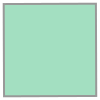

In [17]:
vec = shape(roi.geometry().getInfo())
vec

In [18]:
from xee import helpers

In [19]:
grid_params = helpers.fit_geometry(
    geometry = vec,
    grid_crs = "EPSG:4326",
    grid_scale = (0.00027, -0.00027)
)
grid_params

{'crs': 'EPSG:4326',
 'crs_transform': (0.00027, 0.0, 7.01487, 0.0, -0.00027, 6.28128),
 'shape_2d': (505, 505)}

In [20]:
ds = xr.open_dataset(
    lst_indice_dem,
    engine = 'ee',
    **grid_params
)
ds

<xarray.Dataset> Size: 36MB
Dimensions:         (time: 1, y: 505, x: 505)
Coordinates:
  * time            (time) datetime64[ns] 8B 2024-12-19T09:44:57.392000
  * y               (y) float64 4kB 6.281 6.281 6.281 6.28 ... 6.146 6.145 6.145
  * x               (x) float64 4kB 7.015 7.015 7.016 ... 7.151 7.151 7.151
Data variables: (12/35)
    SR_B1           (time, y, x) float32 1MB ...
    SR_B2           (time, y, x) float32 1MB ...
    SR_B3           (time, y, x) float32 1MB ...
    SR_B4           (time, y, x) float32 1MB ...
    SR_B5           (time, y, x) float32 1MB ...
    SR_B6           (time, y, x) float32 1MB ...
    ...              ...
    LST_C           (time, y, x) float32 1MB ...
    elevation       (time, y, x) float32 1MB ...
    slope           (time, y, x) float32 1MB ...
    aspect_cos      (time, y, x) float32 1MB ...
    longitude_norm  (time, y, x) float32 1MB ...
    population      (time, y, x) float32 1MB ...

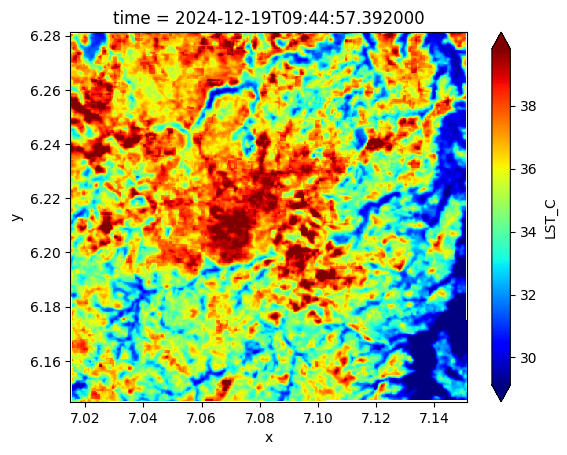

In [21]:
ds.LST_C.plot(
    x = 'x',
    y = 'y',
    cmap = 'jet',
    robust = True
)

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — LSMA + LULC  (unchanged from your original)
# ─────────────────────────────────────────────────────────────────────────────
sentinel_lulc = (
    ee.ImageCollection("projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS")
    .filterDate('2024')
    .select('b1')
    .filterBounds(roi)
    .map(lambda img: img.clip(roi))
    .map(lambda img: img.remap(
        [1, 2, 4, 5, 7, 8, 9, 10, 11],
        [1, 2, 2, 2, 3, 4, 4, 4,  4]
    ))
    .mosaic()
)

In [23]:
# Spectral endmembers (your values — unchanged)
spectra_list_dict = [
    {'SR_B1':0.050064909853463166,'SR_B2':0.07223302015284798,'SR_B3':0.12132719977538706,
     'SR_B4':0.13429919268146087, 'SR_B5':0.10286712279704043,'SR_B6':0.06994348924264733,'SR_B7':0.05162941574916649},
    {'SR_B1':0.03198423382212418, 'SR_B2':0.049716556473792195,'SR_B3':0.08602677453053102,
     'SR_B4':0.09228815905516398, 'SR_B5':0.23703993570883578,'SR_B6':0.21604729349437515,'SR_B7':0.14518889242371297},
    {'SR_B1':0.033417559562693246,'SR_B2':0.053715569874036,'SR_B3':0.09138868529040332,
     'SR_B4':0.11061344262175743, 'SR_B5':0.20210124998438433,'SR_B6':0.21742136997905454,'SR_B7':0.17589079526573345},
    {'SR_B1':0.03985402167306308, 'SR_B2':0.057507135058814725,'SR_B3':0.09422648447181362,
     'SR_B4':0.10725523062936615, 'SR_B5':0.23303521110319197,'SR_B6':0.24408774724917073,'SR_B7':0.17742092580681945}
]

In [24]:
image_for_lsma = complete_clean_image.median().select('SR_B.')
bands          = image_for_lsma.bandNames().getInfo()
endmembers_list= [[spec[b] for b in bands] for spec in spectra_list_dict]

unmixed = (image_for_lsma
           .unmix(endmembers_list, sumToOne=True, nonNegative=True)
           .rename(['water','vegetation','impervious','soil']))

water          = unmixed.select(0)
max_other      = unmixed.select([1,2,3]).reduce(ee.Reducer.max())
water_candidate= water.divide(max_other)

classified_lulc = (
    unmixed.toArray().arrayArgmax().arrayGet([0])
    .where(water_candidate.gte(0.7), 0)
    .rename('lulc')
)

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — COMBINE ALL BANDS FOR MODELLING  (updated: adds 3 new bands)
# ─────────────────────────────────────────────────────────────────────────────
raw_clean_image = (
    lst_indice_dem
    .median()
    .select([
        'NDVI','NDBI','UI','SAVI2','EVI2','NDWI','MNDWI','NDMI','MSAVI',
        'elevation','slope',
        'aspect_cos',       # NEW
        'longitude_norm',   # NEW
        'population',          # NEW
        'LST_C'
    ])
    .clip(roi)
)

combine_images = raw_clean_image.addBands(unmixed)
print("Final band list:", combine_images.bandNames().getInfo())

Final band list: ['NDVI', 'NDBI', 'UI', 'SAVI2', 'EVI2', 'NDWI', 'MNDWI', 'NDMI', 'MSAVI', 'elevation', 'slope', 'aspect_cos', 'longitude_norm', 'population', 'LST_C', 'water', 'vegetation', 'impervious', 'soil']


In [26]:
combine_images

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — MODELLING DATASET  (updated xee call + coordinate rename)
# ─────────────────────────────────────────────────────────────────────────────
modelling_ds = xr.open_dataset(
    combine_images,
    engine   = 'ee',
    **grid_params
)
modelling_ds

/usr/local/lib/python3.13/dist-packages/xee/ext.py:615: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


<xarray.Dataset> Size: 19MB
Dimensions:         (time: 1, y: 505, x: 505)
Coordinates:
  * time            (time) int64 8B 0
  * y               (y) float64 4kB 6.281 6.281 6.281 6.28 ... 6.146 6.145 6.145
  * x               (x) float64 4kB 7.015 7.015 7.016 ... 7.151 7.151 7.151
Data variables: (12/19)
    NDVI            (time, y, x) float32 1MB ...
    NDBI            (time, y, x) float32 1MB ...
    UI              (time, y, x) float32 1MB ...
    SAVI2           (time, y, x) float32 1MB ...
    EVI2            (time, y, x) float32 1MB ...
    NDWI            (time, y, x) float32 1MB ...
    ...              ...
    population      (time, y, x) float32 1MB ...
    LST_C           (time, y, x) float32 1MB ...
    water           (time, y, x) float32 1MB ...
    vegetation      (time, y, x) float32 1MB ...
    impervious      (time, y, x) float32 1MB ...
    soil            (time, y, x) float32 1MB ...

In [28]:
# ── Handle coordinate names (xee >= 0.0.9 uses 'lon'/'lat' not 'x'/'y') ─────
# Check which coordinate names are present and standardise to lon/lat
if 'X' in modelling_ds.dims or 'x' in modelling_ds.dims:
    # Old xee: rename x→lon, y→lat
    x_name = 'X' if 'X' in modelling_ds.dims else 'x'
    y_name = 'Y' if 'Y' in modelling_ds.dims else 'y'
    modelling_ds = modelling_ds.rename({x_name: 'lon', y_name: 'lat'})

# Squeeze time if present
if 'time' in modelling_ds.dims:
    modelling_ds = modelling_ds.squeeze('time', drop=True)

In [29]:
modelling_ds = modelling_ds * 1   # materialise lazy arrays
print(modelling_ds)

<xarray.Dataset> Size: 19MB
Dimensions:         (lat: 505, lon: 505)
Coordinates:
  * lat             (lat) float64 4kB 6.281 6.281 6.281 ... 6.146 6.145 6.145
  * lon             (lon) float64 4kB 7.015 7.015 7.016 ... 7.151 7.151 7.151
Data variables: (12/19)
    NDVI            (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    NDBI            (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    UI              (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    SAVI2           (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    EVI2            (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    NDWI            (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    ...              ...
    population      (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    LST_C           (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
    water           (lat, lon) float32 1MB nan nan nan nan ... nan nan nan nan
  

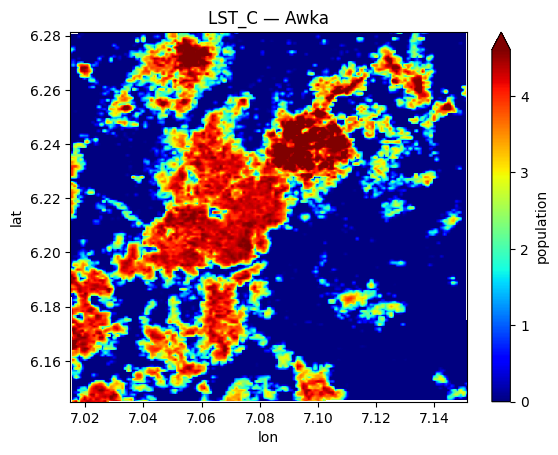

In [30]:
# Quick LST plot to verify
modelling_ds['population'].plot(
    x='lon',
    y='lat',
    cmap='jet',
    robust=True
)
plt.title(f"LST_C — {current_location}")
plt.show()

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — CONVERT TO PANDAS DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
modelling_df = modelling_ds.to_dataframe().dropna()

# The index should now be (time, lon, lat) or (lon, lat)
# Reset so lon and lat become plain columns (needed for modelling cells)
modelling_df = modelling_df.rename(
        columns={'longitude_norm':'location',
                 'pop_log':'population',
                 'aspect_cos':'aspect'
                 })

modelling_df = modelling_df.reset_index()

# Ensure lon and lat are columns (not just index levels)
if 'lon' not in modelling_df.columns:
    modelling_df = modelling_df.rename(columns={'longitude':'lon','latitude':'lat'})

print(f"Dataset shape: {modelling_df.shape}")
print(f"Columns: {modelling_df.columns.tolist()}")
print(f"LST range: {modelling_df['LST_C'].min():.2f} – {modelling_df['LST_C'].max():.2f} °C")
print(f"\nNew variables present:")
print(f"  Aspect:     {modelling_df['aspect'].describe().to_dict()}")
print(f"  Longitude: {modelling_df['location'].describe().to_dict()}")
print(f"  Population:        {modelling_df['population'].describe().to_dict()}")

Dataset shape: (248532, 21)
Columns: ['lat', 'lon', 'NDVI', 'NDBI', 'UI', 'SAVI2', 'EVI2', 'NDWI', 'MNDWI', 'NDMI', 'MSAVI', 'elevation', 'slope', 'aspect', 'location', 'population', 'LST_C', 'water', 'vegetation', 'impervious', 'soil']
LST range: 27.37 – 43.87 °C

New variables present:
  Aspect:     {'count': 248532.0, 'mean': 0.08321864157915115, 'std': 0.6815950870513916, 'min': -1.0, '25%': -0.5524434447288513, '50%': 0.0989314615726471, '75%': 0.7050484418869019, 'max': 1.0}
  Longitude: {'count': 248532.0, 'mean': 0.5018325448036194, 'std': 0.28554826974868774, 'min': 0.007408039644360542, '25%': 0.25588905811309814, '50%': 0.502382218837738, '75%': 0.7488753795623779, 'max': 0.9993442296981812}
  Population:        {'count': 248532.0, 'mean': 1.39989173412323, 'std': 1.6586050987243652, 'min': 0.0, '25%': 0.0, '50%': 0.3723367005586624, '75%': 2.8995959162712097, 'max': 5.381343841552734}


In [32]:
modelling_df.head()

,lat,lon,NDVI,NDBI,UI,SAVI2,EVI2,NDWI,MNDWI,NDMI,...,elevation,slope,aspect,location,population,LST_C,water,vegetation,impervious,soil
0,6.280605,7.051725,0.395250,0.007784,-0.149468,0.423540,0.240254,-0.493802,-0.499666,-0.007784,...,94.0,2.562210,0.241165,0.269804,2.485821,37.833385,0.0,0.0,0.0,1.0
1,6.280605,7.051995,0.352538,0.053748,-0.079515,0.411362,0.215293,-0.473206,-0.513884,-0.053748,...,94.0,2.562210,0.241165,0.271792,1.441366,37.894909,0.0,0.0,0.0,1.0
2,6.280605,7.052265,0.344563,0.012592,-0.123568,0.416023,0.213467,-0.473501,-0.483212,-0.012592,...,94.0,2.562210,0.241165,0.273780,1.689649,37.792370,0.0,0.0,0.0,1.0
3,6.280605,7.052535,0.401791,0.019605,-0.149437,0.417118,0.240237,-0.499165,-0.513743,-0.019605,...,98.0,2.653584,0.349274,0.275768,1.888386,37.559944,0.0,0.0,0.0,1.0
4,6.280605,7.052805,0.347906,0.020799,-0.074731,0.388056,0.203318,-0.447285,-0.463769,-0.020799,...,98.0,2.653584,0.349274,0.277755,2.054100,37.484749,0.0,0.0,0.0,1.0


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — UPDATE VARIABLE GROUPS  (add new variables to selection pool)
#
# In your Cell D+E (feature selection), update variable_groups to include
# the three new variables. They will compete within their groups and only
# enter the model if they pass VIF — fully automatic.
# ─────────────────────────────────────────────────────────────────────────────
# REPLACE your existing variable_groups dict with this:
variable_groups = {
    "vegetation" : ["NDVI", "FVC", "EVI2", "SAVI2", "MSAVI", "vegetation"],
    "builtup"    : ["NDBI", "UI", "impervious"],
    "moisture"   : ["NDMI", "MNDWI", "water"],
    "topography" : ["elevation", "slope", "aspect"],  # aspect_cos added
    "population" : ["population"],                    # NEW group
    "location"   : ["location"],                      # NEW group (supervisor's)
    "soil"       : ["soil"],
}

# NOTE: population and location each have only one candidate so they will
# always be accepted unless they are collinear with already-accepted features.
# The VIF guard will catch any collinearity automatically.


# ─────────────────────────────────────────────────────────────────────────────
# QUICK VALIDATION — check correlation of new variables with LST
# (run after modelling_df is built, before Cell D+E)
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import pearsonr

new_vars = ['aspect', 'location', 'population']
print(f"\n=== NEW VARIABLE CORRELATIONS WITH LST — {current_location} ===")
for v in new_vars:
    if v in modelling_df.columns:
        r, p = pearsonr(modelling_df[v], modelling_df['LST_C'])
        sig  = "✓ significant" if p < 0.05 else "not significant"
        print(f"  {v:<20}  r={r:+.4f}  p={p:.4f}  {sig}")
    else:
        print(f"  {v:<20}  NOT FOUND in dataset")

# Expected for Onitsha:
#   aspect_cos:     moderate negative r (south-facing = hotter → cos negative)
#   longitude_norm: moderate r (east bank of Niger = different LST pattern)
#   pop_log:        positive r (denser areas = hotter)


=== NEW VARIABLE CORRELATIONS WITH LST — Awka ===
  aspect                r=-0.0599  p=0.0000  ✓ significant
  location              r=-0.3915  p=0.0000  ✓ significant
  population            r=+0.4039  p=0.0000  ✓ significant


In [34]:
# =============================================================================
# LST MODELLING — Awka / Onitsha / Nnewi
# =============================================================================
# Run the cells below in order, top to bottom.
# Restart the runtime before you switch to a different city.
#
# What each part does:
#   A   install packages and import them
#   B   build the modelling table and set up the output folders
#   C   check that nearby pixels have similar temperatures
#   C2  measure how far "nearby" actually reaches (the variogram)
#   C3  turn that distance into a square size and a safety gap
#   G   cut the map into squares and hold one band back for testing
#   G5  throw away training pixels that sit too close to what we are predicting
#   D+E pick the predictors, using training pixels only
#   G3  build the X and y tables the models need
#   G4  draw the map of the squares
#   H   tune the three models
#   I   score them on the held-back band
#   I2  hold out each band in turn, to see if the choice of band mattered
#   J2  SHAP — which predictors mattered most
#   N   predict everywhere and save the maps
#   M   check whether the leftover error is still patchy
#   Z   write the summary CSVs
# =============================================================================

# Install the packages. Already-installed ones are skipped, so this is quick
# the second time you run it.
!pip install spatial-kfold lazypredict xgboost lightgbm rasterio shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.3 MB/s eta 0:00:00


In [35]:
# ── A — imports ──────────────────────────────────────────────────────────────
# Everything the rest of the notebook needs, in one place.

import warnings
warnings.filterwarnings("ignore")

import os
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from scipy.stats import pearsonr
from scipy.spatial import cKDTree

from sklearn.model_selection import train_test_split, GroupKFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import libpysal
from esda.moran import Moran
from splot.esda import moran_scatterplot

import rasterio
import rioxarray

print("Imports done.")

Imports done.


In [36]:
# ── B — where the results go ─────────────────────────────────────────────────
# One folder per city, plus a shared folder the three cities all write into.

BASE_DIR   = "/content/drive/MyDrive/Anambra_lst_modelling"
OUT_DIR    = f"{BASE_DIR}/{current_location}_results"
SHARED_DIR = f"{BASE_DIR}/_shared"

for folder in (BASE_DIR, OUT_DIR, SHARED_DIR):
    os.makedirs(folder, exist_ok=True)

print(f"City        : {current_location}")
print(f"Results go to : {OUT_DIR}")
print(f"Shared folder : {SHARED_DIR}")

City        : Awka
Results go to : /content/drive/MyDrive/Anambra_lst_modelling/Awka_results
Shared folder : /content/drive/MyDrive/Anambra_lst_modelling/_shared


In [37]:
# ── B — build the table we will model ────────────────────────────────────────
# modelling_df comes from CELL 17. We drop the time index, throw away any rows
# with missing values, and add FVC if it is not already there.

TARGET = "LST_C"      # the thing we are predicting
COORDS = ["lon", "lat"]

df = modelling_df.copy()
df = df.reset_index().drop(columns=["time"], errors="ignore")
df = df.dropna()

# FVC = how much of a pixel is covered by plants. Worked out from NDVI if the
# earlier cells did not already make it.
if "NDVI" in df.columns and "FVC" not in df.columns:
    ndvi_low  = df["NDVI"].min()
    ndvi_high = df["NDVI"].max()
    df["FVC"] = ((df["NDVI"] - ndvi_low) / (ndvi_high - ndvi_low + 1e-9)).clip(0, 1)

print(f"\nRows kept    : {len(df):,}")
print(f"Columns      : {len(df.columns)}")
print(f"LST range    : {df[TARGET].min():.2f} to {df[TARGET].max():.2f} degC")


Rows kept    : 248,532
Columns      : 23
LST range    : 27.37 to 43.87 degC


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL B3 — RUN RECORD
# A plain dictionary of the choices this run made, written to a JSON file
# next to the figures, so every number in the methods can be traced back.
# ─────────────────────────────────────────────────────────────────────────────
# A plain dictionary that records the choices this run made (block size,
# variogram ranges, number of folds, which block was held out). save_config()
# writes it to a JSON file next to the figures, so every number in the methods
# section can be traced back to the run that produced it.

import os, json, datetime

os.makedirs(OUT_DIR, exist_ok=True)
CONFIG_PATH = f"{OUT_DIR}/run_config.json"

if "CONFIG" not in globals():
    if os.path.exists(CONFIG_PATH):          # reload after a runtime restart
        with open(CONFIG_PATH) as fh:
            CONFIG = json.load(fh)
        print(f"CONFIG reloaded from {CONFIG_PATH}")
    else:
        CONFIG = {"city": current_location}
        print("CONFIG created (empty)")

def save_config():
    """Write CONFIG to disk. Safe to call as often as you like."""
    CONFIG["city"]         = current_location
    CONFIG["last_updated"] = datetime.datetime.now().isoformat(timespec="seconds")
    with open(CONFIG_PATH, "w") as fh:
        json.dump(CONFIG, fh, indent=2, default=str)
    print(f"CONFIG saved -> {CONFIG_PATH}  ({len(CONFIG)} entries)")

save_config()

CONFIG created (empty)
CONFIG saved -> /content/drive/MyDrive/Anambra_lst_modelling/Awka_results/run_config.json  (2 entries)



=== PRE-MODEL MORAN'S I — Awka ===
  Moran's I : 0.9840
  p-value   : 0.0010
  → Spatial autocorrelation confirmed — spatial CV is required.


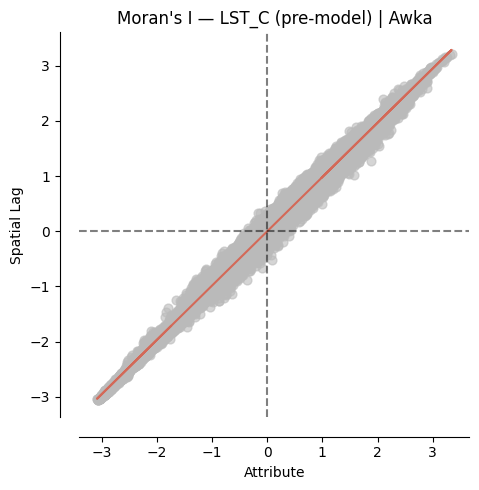

In [39]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL C — PRE-MODEL MORAN'S I
# Confirms spatial autocorrelation in LST — justifies using spatial CV.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
w_pre = libpysal.weights.KNN.from_array(df[COORDS].values, k=8)
w_pre.transform = "r"
moran_pre = Moran(df[TARGET].values, w_pre)

print(f"\n=== PRE-MODEL MORAN'S I — {current_location} ===")
print(f"  Moran's I : {moran_pre.I:.4f}")
print(f"  p-value   : {moran_pre.p_sim:.4f}")
print("  → Spatial autocorrelation confirmed — spatial CV is required."
      if moran_pre.p_sim < 0.05
      else "  → No significant spatial autocorrelation detected.")

fig, ax = plt.subplots(figsize=(7, 5))
moran_scatterplot(moran_pre, ax=ax)
ax.set_title(f"Moran's I — LST_C (pre-model) | {current_location}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_morans_I_premodel.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL C2 — PART 1 : SEMIVARIOGRAM COMPUTATION (this city only, standalone)
# ─────────────────────────────────────────────────────────────────────────────
# WHAT THIS CELL DOES, in plain English
#   1. Finds the LST column and the pixel coordinates in your modelling table.
#   2. Converts coordinates to metres (UTM zone 32N) if they are lon/lat.
#   3. Removes the smooth city-wide temperature gradient (a 2nd-order trend
#      surface). Without this the variogram never flattens and the fitted
#      "range" is meaningless — that is what went wrong in the old figures.
#   4. Bins every pair of pixels by separation distance and computes the
#      semivariance in each bin.
#   5. Fits a spherical model using Cressie weights, so the SHORT lags (the
#      ones that set the range) actually control the fit.
#   6. Writes the result to a small JSON + CSV in a shared folder, so the
#      three-panel figure can be assembled later WITHOUT merging notebooks.

import os, json, numpy as np, pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit

# ── settings you may tune ────────────────────────────────────────────────────
VARIO_N_SAMPLE   = 6000      # pixels drawn for the variogram (6000 -> ~18M pairs)
VARIO_N_BINS     = 20        # number of lag bins
VARIO_LAG_FRAC   = 0.45      # longest lag = 45 % of the ROI diagonal
VARIO_DETREND    = True      # remove the smooth E/N gradient first (keep True)
UTM_EPSG         = 32632     # UTM zone 32N — correct for Anambra State
RANDOM_STATE     = 42

# ── locate the modelling dataframe, whatever you called it ───────────────────
DF = None
for _name in ("df_model", "df_all", "model_df", "df"):
    if _name in globals() and isinstance(globals()[_name], pd.DataFrame):
        DF, DF_NAME = globals()[_name], _name
        break
if DF is None:
    raise RuntimeError("No modelling DataFrame found — run CELL B (DATA PREP) first.")
print(f"Using dataframe : {DF_NAME}  ({len(DF):,} rows)")

def _pick(frame, options, what):
    """Return the first column name in `options` that exists in `frame`."""
    for c in options:
        if c in frame.columns:
            return c
    raise KeyError(f"Could not find the {what} column. Available: {list(frame.columns)[:25]}")

LST_COL = _pick(DF, ["LST_C", "lst_c", "LST", "lst", "LST_Celsius"], "LST")

# ── coordinates in metres ────────────────────────────────────────────────────
if not {"x_m", "y_m"}.issubset(DF.columns):
    if {"x", "y"}.issubset(DF.columns) and DF["x"].abs().max() > 1000:
        DF["x_m"], DF["y_m"] = DF["x"].astype(float), DF["y"].astype(float)
    else:
        lon_col = _pick(DF, ["longitude", "lon", "x", "X"], "longitude")
        lat_col = _pick(DF, ["latitude",  "lat", "y", "Y"], "latitude")
        from pyproj import Transformer
        _tf = Transformer.from_crs("EPSG:4326", f"EPSG:{UTM_EPSG}", always_xy=True)
        _xm, _ym = _tf.transform(DF[lon_col].values, DF[lat_col].values)
        DF["x_m"], DF["y_m"] = _xm, _ym
    print(f"Coordinates      : projected to EPSG:{UTM_EPSG} (metres)")

# ── ROI extent and the longest lag we are allowed to trust ───────────────────
roi_width_m  = float(DF["x_m"].max() - DF["x_m"].min())
roi_height_m = float(DF["y_m"].max() - DF["y_m"].min())
roi_diag_m   = float(np.hypot(roi_width_m, roi_height_m))
max_lag      = float(VARIO_LAG_FRAC * roi_diag_m)      # never exceed ~half the ROI
print(f"ROI extent       : {roi_width_m/1000:.1f} x {roi_height_m/1000:.1f} km"
      f"  (diagonal {roi_diag_m/1000:.1f} km)")
print(f"Maximum lag used : {max_lag:,.0f} m  ({VARIO_LAG_FRAC:.0%} of the diagonal)")

Using dataframe : df  (248,532 rows)
Coordinates      : projected to EPSG:32632 (metres)
ROI extent       : 14.9 x 14.9 km  (diagonal 21.1 km)
Maximum lag used : 9,508 m  (45% of the diagonal)


In [41]:
# ── draw the sample ──────────────────────────────────────────────────────────
_cols = ["x_m", "y_m", LST_COL]
_samp = (DF[_cols].dropna()
                  .sample(n=min(VARIO_N_SAMPLE, len(DF)), random_state=RANDOM_STATE)
                  .reset_index(drop=True))
XY = _samp[["x_m", "y_m"]].to_numpy(float)
z  = _samp[LST_COL].to_numpy(float)
n  = len(z)
print(f"Sample drawn     : {n:,} pixels  ({n*(n-1)//2:,} pairs)")

# ── step 3 : remove the smooth city-wide trend ───────────────────────────────
if VARIO_DETREND:
    e_km = (XY[:, 0] - XY[:, 0].mean()) / 1000.0        # eastings in km, centred
    n_km = (XY[:, 1] - XY[:, 1].mean()) / 1000.0        # northings in km, centred
    A    = np.column_stack([np.ones(n), e_km, n_km, e_km**2, e_km*n_km, n_km**2])
    beta, *_ = np.linalg.lstsq(A, z, rcond=None)
    trend    = A @ beta
    z_used   = z - trend                                # residual field
    trend_r2 = 1.0 - np.var(z_used) / np.var(z)
    print(f"Trend removed    : 2nd-order surface explains {trend_r2:6.1%} of LST variance")
else:
    z_used, trend_r2 = z.copy(), np.nan

# ── step 4 : bin the pairs (chunked, so memory stays small) ──────────────────
edges  = np.linspace(0.0, max_lag, VARIO_N_BINS + 1)
sum_g  = np.zeros(VARIO_N_BINS)          # sum of squared differences per bin
sum_h  = np.zeros(VARIO_N_BINS)          # sum of distances per bin
cnt    = np.zeros(VARIO_N_BINS)          # number of pairs per bin
CHUNK  = 512

for i0 in range(0, n, CHUNK):
    i1   = min(i0 + CHUNK, n)
    D    = cdist(XY[i0:i1], XY)                          # distances, metres
    DZ   = z_used[i0:i1, None] - z_used[None, :]         # value differences
    rows = np.arange(i0, i1)[:, None]
    cols = np.arange(n)[None, :]
    keep = (cols > rows) & (D > 0) & (D <= max_lag)      # upper triangle only
    if not keep.any():
        continue
    h_k  = D[keep]
    g_k  = DZ[keep] ** 2
    idx  = np.clip(np.digitize(h_k, edges) - 1, 0, VARIO_N_BINS - 1)
    sum_g += np.bincount(idx, weights=g_k, minlength=VARIO_N_BINS)
    sum_h += np.bincount(idx, weights=h_k, minlength=VARIO_N_BINS)
    cnt   += np.bincount(idx,               minlength=VARIO_N_BINS)

_ok         = cnt > 30                                   # ignore near-empty bins
lag_centres = (sum_h / np.maximum(cnt, 1))[_ok]           # mean distance in bin
gamma_bin   = (0.5 * sum_g / np.maximum(cnt, 1))[_ok]     # semivariance, degC^2
pair_counts = cnt[_ok]
print(f"Lag bins kept    : {len(gamma_bin)} of {VARIO_N_BINS}")

Sample drawn     : 6,000 pixels  (17,997,000 pairs)
Trend removed    : 2nd-order surface explains  37.5% of LST variance
Lag bins kept    : 20 of 20


In [42]:
# ── step 5 : fit the spherical model ─────────────────────────────────────────
def spherical(h, nugget, psill, rng):
    """Spherical semivariogram. nugget = value at h->0, psill = rise above it,
       rng = range, the distance at which the curve reaches the sill."""
    h  = np.asarray(h, dtype=float)
    hr = np.minimum(h / rng, 1.0)
    return nugget + psill * (1.5 * hr - 0.5 * hr ** 3)

g_max  = float(gamma_bin.max())
p0     = [max(gamma_bin[0] * 0.5, 1e-3), g_max, max_lag / 3.0]
bounds = ([0.0, 1e-6, edges[1]], [0.9 * g_max, 3.0 * g_max, 2.0 * max_lag])
# Cressie weights: relative error, so small-gamma (short-lag) bins carry weight
sigma  = np.maximum(gamma_bin, 1e-6) / np.sqrt(pair_counts)

popt, _pcov = curve_fit(spherical, lag_centres, gamma_bin,
                        p0=p0, bounds=bounds, sigma=sigma,
                        absolute_sigma=False, maxfev=20000)

nugget, psill, vario_range = (float(v) for v in popt)
sill       = nugget + psill
nugget_pct = 100.0 * nugget / sill
_fitted    = spherical(lag_centres, *popt)
fit_r2     = 1.0 - np.sum((gamma_bin - _fitted) ** 2) / np.sum((gamma_bin - gamma_bin.mean()) ** 2)

print("\nFitted spherical model")
print(f"  Range        : {vario_range:8,.0f} m")
print(f"  Sill         : {sill:8.2f} degC^2")
print(f"  Nugget       : {nugget:8.2f} degC^2   ({nugget_pct:.1f} % of sill)")
print(f"  Fit R2       : {fit_r2:8.3f}")

# ── plateau / stationarity diagnostics ───────────────────────────────────────
plateau_ratio = float(np.mean(gamma_bin[-3:]) / sill)
if vario_range > 0.85 * max_lag:
    print("\n  WARNING: range is close to the maximum lag — it is probably an\n"
          "           artefact of the lag cap. Raise VARIO_LAG_FRAC or keep\n"
          "           VARIO_DETREND = True.")
elif plateau_ratio > 1.05:
    print(f"\n  WARNING: the last bins sit {100*(plateau_ratio-1):.0f} % above the fitted sill —\n"
          "           residual large-scale structure remains. Range is a lower bound.")
else:
    print("\n  OK: the empirical curve reaches a plateau below the maximum lag,\n"
          "      so the fitted range is a real correlation length.")
if nugget_pct > 25:
    print(f"  NOTE: nugget is {nugget_pct:.0f} % of the sill ({np.sqrt(nugget):.2f} degC).\n"
          "        Landsat 9 TIRS noise is ~0.2 K, so most of this is genuine\n"
          "        sub-100 m thermal heterogeneity, not sensor noise.")

# ── step 6 : export for the (optional) three-panel figure ────────────────────
SHARED_DIR = f"{BASE_DIR}/_shared"
os.makedirs(SHARED_DIR, exist_ok=True)
os.makedirs(OUT_DIR,    exist_ok=True)

VARIO_SUMMARY = {
    "city":            current_location,
    "range_m":         vario_range,
    "sill":            sill,
    "nugget":          nugget,
    "nugget_pct":      nugget_pct,
    "fit_r2":          fit_r2,
    "max_lag_m":       max_lag,
    "n_sample":        int(n),
    "detrended":       bool(VARIO_DETREND),
    "trend_r2":        None if np.isnan(trend_r2) else float(trend_r2),
    "plateau_ratio":   plateau_ratio,
    "roi_width_m":     roi_width_m,
    "roi_height_m":    roi_height_m,
}
with open(f"{SHARED_DIR}/{current_location}_variogram.json", "w") as _f:
    json.dump(VARIO_SUMMARY, _f, indent=2)

pd.DataFrame({"lag_m": lag_centres, "semivariance": gamma_bin, "n_pairs": pair_counts}) \
  .to_csv(f"{SHARED_DIR}/{current_location}_variogram_points.csv", index=False)

print(f"\nSaved -> {SHARED_DIR}/{current_location}_variogram.json")
print(f"Saved -> {SHARED_DIR}/{current_location}_variogram_points.csv")


Fitted spherical model
  Range        :    3,156 m
  Sill         :     4.09 degC^2
  Nugget       :     2.04 degC^2   (50.0 % of sill)
  Fit R2       :    0.948

  OK: the empirical curve reaches a plateau below the maximum lag,
      so the fitted range is a real correlation length.
  NOTE: nugget is 50 % of the sill (1.43 degC).
        Landsat 9 TIRS noise is ~0.2 K, so most of this is genuine
        sub-100 m thermal heterogeneity, not sensor noise.

Saved -> /content/drive/MyDrive/Anambra_lst_modelling/_shared/Awka_variogram.json
Saved -> /content/drive/MyDrive/Anambra_lst_modelling/_shared/Awka_variogram_points.csv


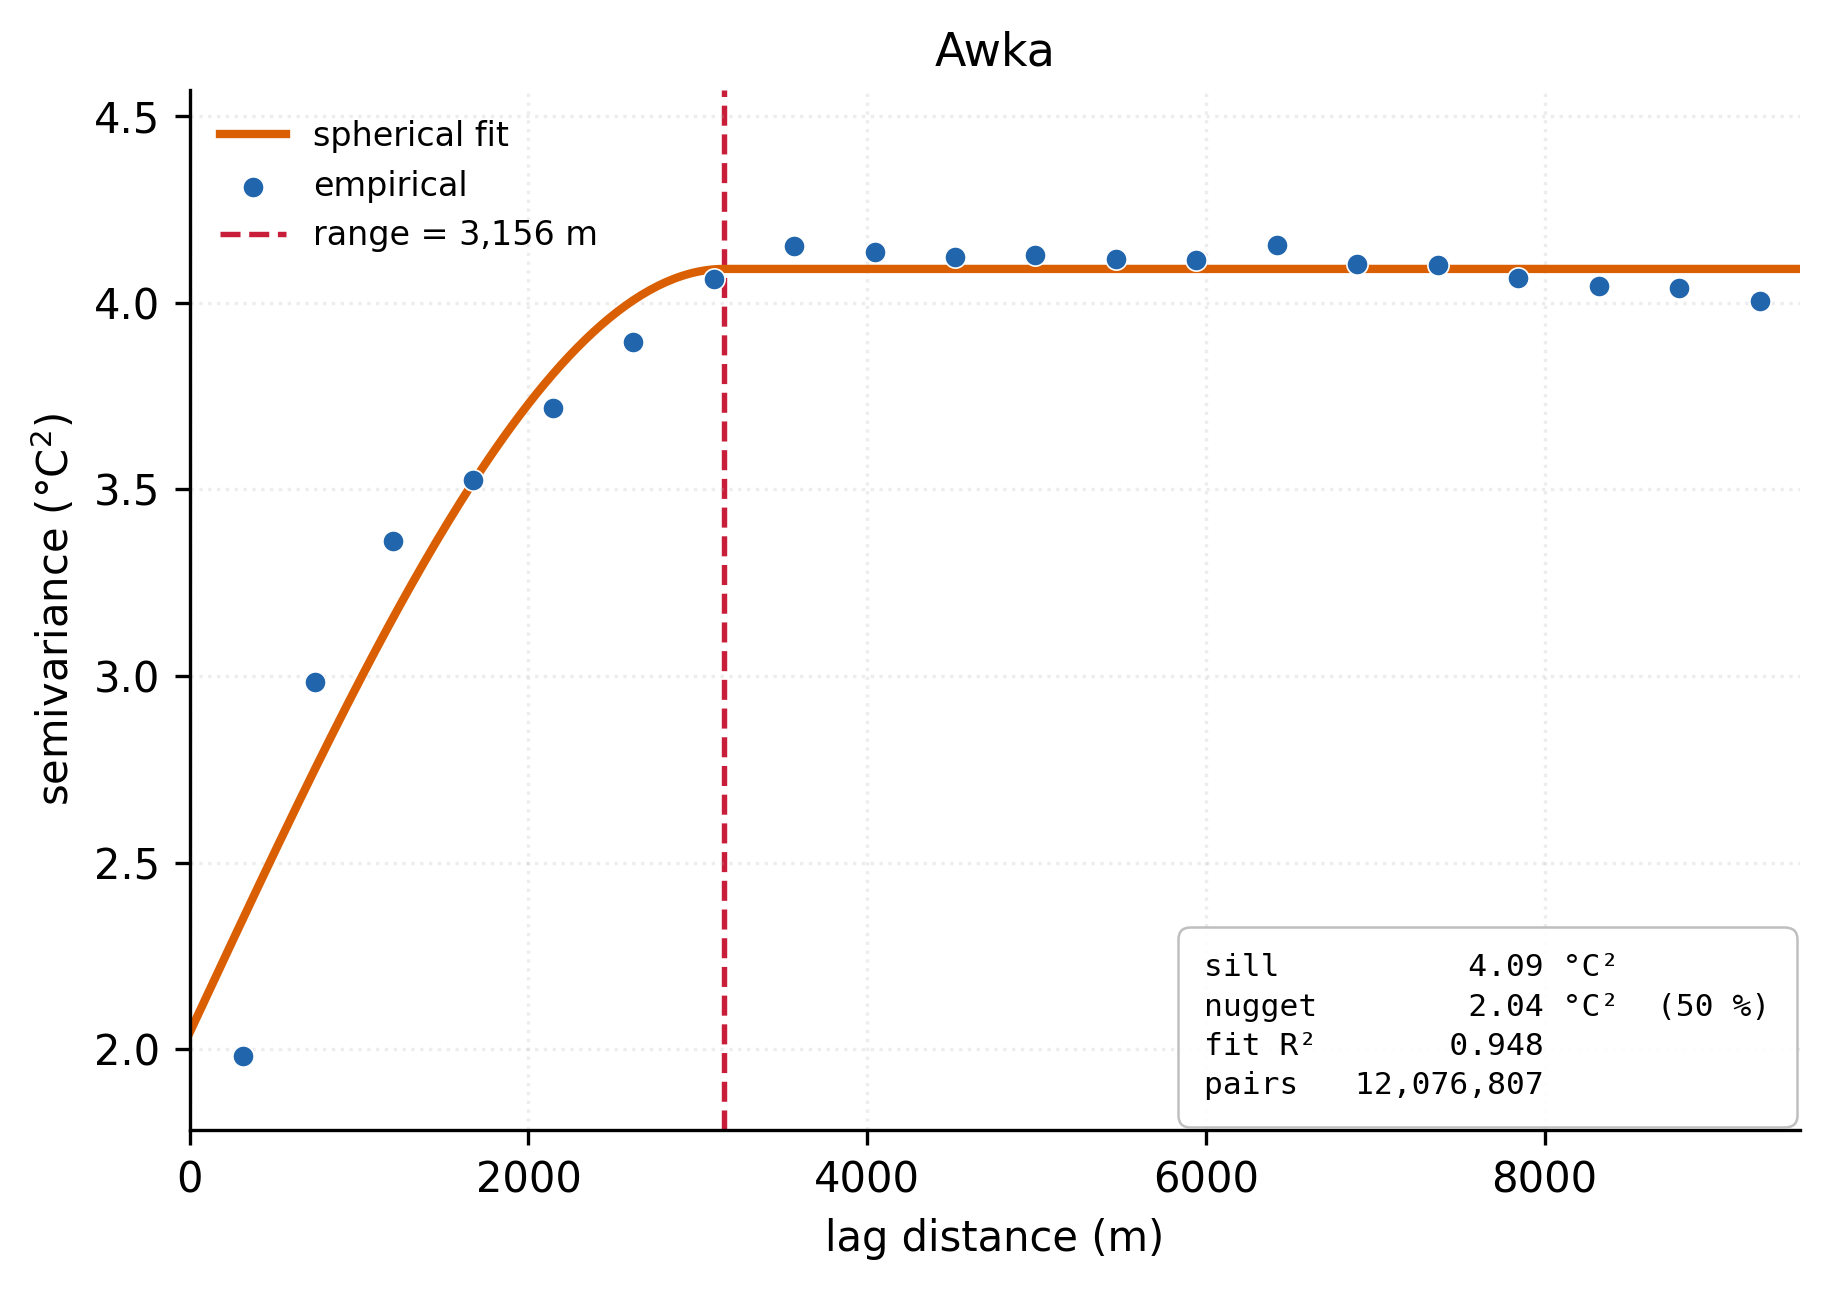

This city's range rounds to a block size of 3,500 m


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL C2 — PART 2 : SEMIVARIOGRAM FIGURE (single panel, this city)
# ─────────────────────────────────────────────────────────────────────────────
# Fixed three-colour palette only — no random colours, no colour riot.
#   points = muted blue, model = warm orange, range marker = crimson dashed.

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

POINT_C = "#2166ac"     # empirical semivariance  (muted blue)
MODEL_C = "#d95f02"     # fitted spherical model  (warm orange)
GUIDE_C = "#c81e3a"     # range marker            (crimson)
GRID_C  = "#b8b8b8"     # gridlines               (light grey)

h_fine = np.linspace(0.0, max_lag, 400)
y_all  = np.r_[gamma_bin, spherical(h_fine, *popt)]
y_min  = 0.90 * float(y_all.min())
y_max  = 1.10 * float(y_all.max())

fig, ax = plt.subplots(figsize=(6.2, 4.4), dpi=300)

ax.plot(h_fine, spherical(h_fine, *popt), color=MODEL_C, lw=2.0,
        label="spherical fit", zorder=2)
ax.scatter(lag_centres, gamma_bin, s=26, color=POINT_C,
           edgecolor="white", linewidth=0.4, label="empirical", zorder=3)
ax.axvline(vario_range, color=GUIDE_C, ls="--", lw=1.3,
           label=f"range = {vario_range:,.0f} m", zorder=1)

info_text = "\n".join([
    f"{'sill':<8}{sill:>10.2f} °C²",
    f"{'nugget':<8}{nugget:>10.2f} °C²  ({nugget_pct:.0f} %)",
    f"{'fit R²':<8}{fit_r2:>10.3f}",
    f"{'pairs':<8}{int(pair_counts.sum()):>10,d}",
])
info_box = AnchoredText(info_text, loc="lower right", pad=0.45, borderpad=0.5,
                        frameon=True,
                        prop=dict(family="DejaVu Sans Mono", size=7.5,
                                  multialignment="left", linespacing=1.45))
info_box.patch.set(boxstyle="round,pad=0.4", fc="white", ec=GRID_C, lw=0.6, alpha=0.9)
ax.add_artist(info_box)

ax.set_xlabel("lag distance (m)")
ax.set_ylabel("semivariance ($\\degree$C$^2$)")
ax.set_title(current_location, fontsize=11)
ax.set_xlim(0, max_lag)
ax.set_ylim(y_min, y_max)
ax.grid(True, color=GRID_C, ls=":", alpha=0.25)
for _s in ("top", "right"):
    ax.spines[_s].set_visible(False)
ax.legend(loc="upper left", frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(f"{OUT_DIR}/F04_{current_location}_semivariogram.png",
            dpi=300, bbox_inches="tight")
plt.show()

# Block size for THIS city, rounded up to the nearest 500 m.
# The final value used in the paper is the largest of the three cities —
# CELL C3 works that out from the shared folder.
BLOCK_FROM_VARIOGRAM = int(np.ceil(vario_range / 500.0) * 500)
print(f"This city's range rounds to a block size of {BLOCK_FROM_VARIOGRAM:,} m")

In [44]:
# ── C3 — square size and safety gap for THIS city ────────────────────────────
# CELL C2 measured how far temperatures stay similar in this city. We round
# that up to the next 500 m and use it for two things:
#   - the size of the squares the map gets cut into
#   - the safety gap (buffer) between training pixels and test pixels
#
# Why this cell exists at all: CELL G starts with
#     if "BLOCK_SIZE_M" not in globals():
# so if you run Awka and then Onitsha without restarting, Onitsha quietly
# keeps Awka's 3,500 m and nothing in the output tells you. Setting the value
# here every single time makes that impossible.

import glob

# how far temperatures stay similar in this city
if "vario_range" in globals():
    city_range_m = float(vario_range)
else:
    # after a runtime restart, read it back from the file CELL C2 saved
    saved = f"{SHARED_DIR}/{current_location}_variogram.json"
    if not os.path.exists(saved):
        raise RuntimeError(f"No variogram saved for {current_location}. Run CELL C2 PART 1 first.")
    city_range_m = float(json.load(open(saved))["range_m"])

BLOCK_SIZE_M = int(np.ceil(city_range_m / 500.0) * 500)
BUFFER_M     = BLOCK_SIZE_M      # same number, so the gap always clears the range

print(f"{current_location}")
print(f"  temperatures stay similar over : {city_range_m:8,.0f} m")
print(f"  square size                    : {BLOCK_SIZE_M:8,} m")
print(f"  safety gap (buffer)            : {BUFFER_M:8,} m")

Awka
  temperatures stay similar over :    3,156 m
  square size                    :    3,500 m
  safety gap (buffer)            :    3,500 m


In [45]:
# ── C3 — how much training data the gap will cost, and a reminder ────────────
# Rough guess before you run it: the held-back band plus a gap on each side
# comes out of the training data.

roi_width_m  = float(DF["x_m"].max() - DF["x_m"].min()) if "DF" in globals() else np.nan
roi_height_m = float(DF["y_m"].max() - DF["y_m"].min()) if "DF" in globals() else np.nan

if np.isfinite(roi_width_m):
    map_side_m   = min(roi_width_m, roi_height_m)
    training_left = max(0.0, (map_side_m - BLOCK_SIZE_M - 2 * BUFFER_M) / map_side_m)
    print(f"Rough guess at training data left after the gap: {100*training_left:.0f} %")
    if training_left < 0.25:
        print("  That is low. If CELL G5 warns you, set BUFFER_SCOPE = 'cv_only' there.")

# ── what the other cities used ───────────────────────────────────────────────
city_ranges = {}
for path in sorted(glob.glob(f"{SHARED_DIR}/*_variogram.json")):
    record = json.load(open(path))
    city_ranges[record["city"]] = float(record["range_m"])
city_ranges[current_location] = city_range_m

if len(city_ranges) > 1:
    print(f"\nAll cities so far:")
    print(f"  {'city':<12}{'range (m)':>11}{'square (m)':>12}")
    for city, rng in sorted(city_ranges.items(), key=lambda kv: -kv[1]):
        print(f"  {city:<12}{rng:>11,.0f}{int(np.ceil(rng/500)*500):>12,}")

    squares_used = set(int(np.ceil(v / 500) * 500) for v in city_ranges.values())
    if len(squares_used) > 1:
        print("\n  HEADS UP: the cities are using different square sizes, on purpose.")
        print("  Each city is being given a different sized test, so when you write up:")
        print("    - put each city's square size in the methods")
        print("    - do NOT write 'the model did best in city X'")
        print("    - cross-city sentences should be about which variables mattered,")
        print("      not about which city scored higher")

json.dump({"city": current_location, "range_m": city_range_m,
           "block_m": BLOCK_SIZE_M, "buffer_m": BUFFER_M},
          open(f"{SHARED_DIR}/{current_location}_blocking.json", "w"), indent=2)
print(f"\nSaved -> {SHARED_DIR}/{current_location}_blocking.json")

Rough guess at training data left after the gap: 30 %

Saved -> /content/drive/MyDrive/Anambra_lst_modelling/_shared/Awka_blocking.json


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL G — SPATIAL BLOCK HOLDOUT + BLOCKED CV FOLDS (blocking is outermost)
# ─────────────────────────────────────────────────────────────────────────────
# Order of operations, deliberately:
#   1. Lay a regular BLOCK_SIZE_M grid over the ROI.
#   2. Assign every pixel to exactly one block.
#   3. Group the occupied blocks into N_FOLDS + 1 spatially contiguous groups
#      of roughly equal pixel count (serpentine sweep, then equal-count cuts).
#   4. Hold out ONE whole group as the test set (the group closest to the
#      median size, so the test set is neither a sliver nor half the city).
#   5. The remaining N_FOLDS groups become the cross-validation folds.
# Nothing downstream ever sees a random split.

import os, glob, json
import numpy as np, pandas as pd
from scipy.spatial import cKDTree
from sklearn.model_selection import GroupKFold

N_FOLDS             = 5           # number of cross-validation folds
N_BLOCK_GROUPS      = N_FOLDS + 1 # 5 CV folds + 1 spatial holdout
MAX_IMBALANCE       = 3.0         # largest / smallest group must stay below this
MIN_OCCUPIED_BLOCKS = 12          # need enough blocks to cut 6 balanced groups

# ── guard 0 : is the modelling frame ready, with metre coordinates? ──────────
if "DF" not in globals():
    raise RuntimeError("DF is not defined — run CELL C2 PART 1 first (it finds "
                       "your modelling dataframe and adds x_m / y_m).")
if not {"x_m", "y_m"}.issubset(DF.columns):
    raise RuntimeError("DF has no x_m / y_m columns — run CELL C2 PART 1 first.")

# ── guard 1 : is the block size known? ──────────────────────────────────────
if "BLOCK_SIZE_M" not in globals():
    if "BLOCK_FROM_VARIOGRAM" in globals():
        BLOCK_SIZE_M = int(BLOCK_FROM_VARIOGRAM)
        print(f"BLOCK_SIZE_M taken from this city's variogram: {BLOCK_SIZE_M:,} m")
        print("  (run CELL C3 once all three cities have a variogram, so every")
        print("   city uses the same block size in the paper)")
    else:
        found = {}
        for path in sorted(glob.glob(f"{BASE_DIR}/_shared/*_variogram.json")):
            with open(path) as fh:
                rec = json.load(fh)
            found[rec["city"]] = float(rec["range_m"])
        if not found:
            raise RuntimeError(
                "BLOCK_SIZE_M is not defined and no variogram results were found.\n"
                "Run CELL C2 (PART 1 + PART 2), then CELL C3, then this cell.")
        BLOCK_SIZE_M = int(np.ceil(max(found.values()) / 500.0) * 500)
        print(f"BLOCK_SIZE_M recovered from {BASE_DIR}/_shared : {BLOCK_SIZE_M:,} m")

In [47]:
# ── 1-2 : assign every pixel to exactly one block ───────────────────────────
xorigin = float(DF["x_m"].min())
yorigin = float(DF["y_m"].min())
DF["block_x"]  = np.floor((DF["x_m"] - xorigin) / BLOCK_SIZE_M).astype(int)
DF["block_y"]  = np.floor((DF["y_m"] - yorigin) / BLOCK_SIZE_M).astype(int)
DF["block_id"] = DF["block_x"].astype(str) + "_" + DF["block_y"].astype(str)

blocks = (DF.groupby(["block_x", "block_y"], as_index=False)
            .size().rename(columns={"size": "n_pixels"}))
n_occupied = len(blocks)
print(f"\nBlock size       : {BLOCK_SIZE_M:,} m")
print(f"Occupied blocks  : {n_occupied}")
assert n_occupied >= MIN_OCCUPIED_BLOCKS, (
    f"Only {n_occupied} occupied blocks — BLOCK_SIZE_M ({BLOCK_SIZE_M:,} m) is too "
    f"coarse for this ROI. This is exactly what produced your 4-fold figure.")

# ── 3 : serpentine sweep, then equal-count cuts ──────────────────────────────
# The sweep walks left-to-right along one row of blocks, right-to-left along the
# next, and so on. Cutting that single path into six equal-count pieces gives
# groups that are BOTH spatially contiguous AND similar in pixel count — which
# is why an ordered colour ramp is a legitimate way to draw them later.
blocks = blocks.sort_values(["block_y", "block_x"]).reset_index(drop=True)
sweep = []
for row_y, row_df in blocks.groupby("block_y", sort=True):
    left_to_right = (row_y % 2 == 0)
    sweep.append(row_df.sort_values("block_x", ascending=left_to_right))
blocks = pd.concat(sweep).reset_index(drop=True)

cumulative = blocks["n_pixels"].cumsum().to_numpy()
targets    = np.arange(1, N_BLOCK_GROUPS) * (cumulative[-1] / N_BLOCK_GROUPS)
cuts       = np.searchsorted(cumulative, targets)
blocks["block_group"] = np.searchsorted(cuts, np.arange(n_occupied), side="right")

DF = DF.drop(columns=["block_group"], errors="ignore").merge(
        blocks[["block_x", "block_y", "block_group"]],
        on=["block_x", "block_y"], how="left")

group_sizes = DF["block_group"].value_counts().sort_index()
print(f"\nBlock groups     : {group_sizes.size} (target {N_BLOCK_GROUPS})")
for gid, gn in group_sizes.items():
    print(f"  group {gid}  {gn:9,d} pixels  ({100 * gn / len(DF):5.1f} %)")

imbalance = float(group_sizes.max() / group_sizes.min())
print(f"\nImbalance ratio  : {imbalance:.2f}  (limit {MAX_IMBALANCE})")
assert group_sizes.size == N_BLOCK_GROUPS, (
    f"Got {group_sizes.size} groups, need exactly {N_BLOCK_GROUPS} — "
    f"GroupKFold(n_splits={N_FOLDS}) would fail. Reduce BLOCK_SIZE_M.")
assert imbalance <= MAX_IMBALANCE, (
    f"Groups differ by {imbalance:.1f}x — reduce BLOCK_SIZE_M so the equal-count "
    f"cuts have finer blocks to work with.")


Block size       : 3,500 m
Occupied blocks  : 25

Block groups     : 6 (target 6)
  group 0     40,990 pixels  ( 16.5 %)
  group 1     34,888 pixels  ( 14.0 %)
  group 2     41,121 pixels  ( 16.5 %)
  group 3     41,146 pixels  ( 16.6 %)
  group 4     47,823 pixels  ( 19.2 %)
  group 5     42,564 pixels  ( 17.1 %)

Imbalance ratio  : 1.37  (limit 3.0)


In [48]:
# ── 4 : hold out the group closest to the median size ────────────────────────
HOLDOUT_GROUP = int((group_sizes - group_sizes.median()).abs().idxmin())
test_mask     = DF["block_group"] == HOLDOUT_GROUP

df_train = DF.loc[~test_mask].reset_index(drop=True)
df_test  = DF.loc[ test_mask].reset_index(drop=True)

print(f"\nHoldout group    : {HOLDOUT_GROUP}")
print(f"  train          : {len(df_train):9,d} pixels ({100*len(df_train)/len(DF):5.1f} %)")
print(f"  test           : {len(df_test):9,d} pixels ({100*len(df_test)/len(DF):5.1f} %)")

# separation diagnostic — how far is the test block from the training data?
train_xy  = df_train[["x_m", "y_m"]].to_numpy(float)
test_xy   = df_test[["x_m", "y_m"]].to_numpy(float)
nn_dist, _junk = cKDTree(train_xy).query(test_xy, k=1)
print(f"  test-to-train nearest-neighbour distance:")
print(f"    minimum      : {nn_dist.min():8,.0f} m")
print(f"    median       : {np.median(nn_dist):8,.0f} m")
if "vario_range" in globals():
    beyond = 100.0 * float((nn_dist > vario_range).mean())
    print(f"    {beyond:.1f} % of test pixels lie beyond the variogram range "
          f"({vario_range:,.0f} m)")

# ── 5 : the remaining groups become the CV folds ─────────────────────────────
gkf = GroupKFold(n_splits=N_FOLDS)
CV_SPLITS = list(gkf.split(df_train, groups=df_train["block_group"].to_numpy()))
print(f"\nBlocked CV folds : {len(CV_SPLITS)}")
for k, (tr_idx, va_idx) in enumerate(CV_SPLITS, start=1):
    held = sorted(df_train.loc[va_idx, "block_group"].unique())
    print(f"  fold {k}  train {len(tr_idx):8,d}  validate {len(va_idx):8,d}"
          f"  (group {held[0]})")
    assert len(va_idx) > 0, f"fold {k} is empty"
assert len(CV_SPLITS) == N_FOLDS, "GroupKFold did not return N_FOLDS folds"

# ── export the block design so the figure cell (and the 3-panel figure) can
#    redraw it without recomputing anything ───────────────────────────────────
SHARED_DIR = f"{BASE_DIR}/_shared"
os.makedirs(SHARED_DIR, exist_ok=True)
blocks_out = blocks.copy()
blocks_out["x_left"]     = xorigin + blocks_out["block_x"] * BLOCK_SIZE_M
blocks_out["y_bottom"]   = yorigin + blocks_out["block_y"] * BLOCK_SIZE_M
blocks_out["block_size"] = BLOCK_SIZE_M
blocks_out["is_holdout"] = (blocks_out["block_group"] == HOLDOUT_GROUP).astype(int)
blocks_out["city"]       = current_location
blocks_out.to_csv(f"{SHARED_DIR}/{current_location}_blocks.csv", index=False)
print(f"\nSaved -> {SHARED_DIR}/{current_location}_blocks.csv")

CONFIG["block_size_m"]   = BLOCK_SIZE_M
CONFIG["n_folds"]        = N_FOLDS
CONFIG["holdout_group"]  = HOLDOUT_GROUP
CONFIG["n_occupied_blk"] = n_occupied
save_config()


Holdout group    : 2
  train          :   207,411 pixels ( 83.5 %)
  test           :    41,121 pixels ( 16.5 %)
  test-to-train nearest-neighbour distance:
    minimum      :       30 m
    median       :      806 m
    0.0 % of test pixels lie beyond the variogram range (3,156 m)

Blocked CV folds : 5
  fold 1  train  159,588  validate   47,823  (group 4)
  fold 2  train  164,847  validate   42,564  (group 5)
  fold 3  train  166,265  validate   41,146  (group 3)
  fold 4  train  166,421  validate   40,990  (group 0)
  fold 5  train  172,523  validate   34,888  (group 1)

Saved -> /content/drive/MyDrive/Anambra_lst_modelling/_shared/Awka_blocks.csv
CONFIG saved -> /content/drive/MyDrive/Anambra_lst_modelling/Awka_results/run_config.json  (6 entries)


In [49]:
# ── G5 — settings for the safety gap ─────────────────────────────────────────
# THE PROBLEM THIS FIXES
#   The held-back band is one square thick, with training data on both sides.
#   So a pixel in the middle of it is only half a square away from something
#   the model has already seen. Pixels that close have nearly the same
#   temperature, so the model can read the answer off its neighbours.
#
#   Your own runs showed this. The "% of test pixels far enough away" column
#   can be worked out from the shape of the grid alone, without looking at any
#   temperatures. Predicted: 0.0, 0.0, 10.0. Measured: 0.0, 0.6, 9.8. So it
#   was never telling you anything about your cities.
#
#   Bigger squares do not help. Awka would need 6.3 km squares and only two of
#   those fit across a 15 km city. So instead we throw away training pixels
#   that sit too close to whatever we are predicting.

APPLY_BUFFER = True       # set False to get the old, un-buffered numbers back

BUFFER_SCOPE = "cv_only"  # "cv_only"      : gap around each CV fold only
                          #                  (recommended — every fold keeps
                          #                   plenty of data)
                          # "both"         : gap around the held-back band too
                          #                  (stricter, but it eats the bands
                          #                   sitting next to the held-back one)
                          # "holdout_only" : gap around the held-back band only

MIN_FOLD_TRAIN_FRAC = 0.20   # stop if a fold keeps less than this much training data
MIN_GROUP_KEEP_FRAC = 0.40   # warn if the gap wipes out a neighbouring band

print(f"Buffer     : {BUFFER_M:,} m  ({'on' if APPLY_BUFFER else 'off'})")
print(f"Applied to : {BUFFER_SCOPE}")

Buffer     : 3,500 m  (on)
Applied to : cv_only


In [50]:
# ── G5 — gap around the held-back band ───────────────────────────────────────
# This shrinks df_train once. The test band itself is never touched, so the
# scores still cover the whole held-back area.

train_rows_before = len(df_train)
df_train_no_buffer = df_train.copy()      # kept in case you want to compare

buffer_the_holdout = APPLY_BUFFER and BUFFER_SCOPE in ("both", "holdout_only")
buffer_the_folds   = APPLY_BUFFER and BUFFER_SCOPE in ("both", "cv_only")

if buffer_the_holdout:
    test_points  = df_test[["x_m", "y_m"]].to_numpy(float)
    train_points = df_train[["x_m", "y_m"]].to_numpy(float)
    distance_to_test, _ = cKDTree(test_points).query(train_points, k=1)

    far_enough = distance_to_test >= BUFFER_M
    df_train = df_train.loc[far_enough].reset_index(drop=True)

    print(f"Training pixels before : {train_rows_before:,}")
    print(f"Removed by the gap     : {(~far_enough).sum():,} "
          f"({100*(~far_enough).sum()/train_rows_before:.1f} %)")
    print(f"Training pixels after  : {len(df_train):,}")

    # which bands did the gap eat? Bands next to the held-back one lose most,
    # and a band cut down to a sliver makes a useless CV fold.
    before = df_train_no_buffer["block_group"].value_counts().sort_index()
    after  = df_train["block_group"].value_counts().sort_index().reindex(before.index).fillna(0)
    eaten  = []
    print(f"\nWhat happened to each remaining band:")
    for band in before.index:
        kept_frac = after[band] / before[band]
        note = "   <-- mostly gone" if kept_frac < MIN_GROUP_KEEP_FRAC else ""
        if kept_frac < MIN_GROUP_KEEP_FRAC:
            eaten.append(int(band))
        print(f"  band {band}: {before[band]:8,.0f} -> {after[band]:8,.0f} pixels "
              f"({100*kept_frac:5.1f} % kept){note}")
    if eaten:
        print(f"\n  WARNING: band(s) {eaten} sat next to the held-back band and lost")
        print(f"  most of their pixels. They will make weak CV folds. Set")
        print(f"  BUFFER_SCOPE = 'cv_only' above to avoid this.")

    bands_left = sorted(df_train["block_group"].unique().tolist())
    assert len(bands_left) == N_FOLDS, (
        f"the gap wiped out a whole band — {len(bands_left)} left, need {N_FOLDS}. "
        f"Set BUFFER_SCOPE = 'cv_only'.")

    # how far apart are training and test now?
    train_points_now = df_train[["x_m", "y_m"]].to_numpy(float)
    gap_now, _ = cKDTree(train_points_now).query(test_points, k=1)
    print(f"\nGap between test and training pixels, after:")
    print(f"  smallest : {gap_now.min():8,.0f} m   (was 30 m)")
    print(f"  typical  : {np.median(gap_now):8,.0f} m")
    print(f"  {100.0*float((gap_now > city_range_m).mean()):.1f} % of test pixels are now "
          f"further away than {city_range_m:,.0f} m")
else:
    print("Holdout band not buffered (BUFFER_SCOPE does not include it).")

Holdout band not buffered (BUFFER_SCOPE does not include it).


In [51]:
# ── G5 — rebuild the CV folds, each with its own gap ─────────────────────────
# GroupKFold cannot say "train on the other bands MINUS a gap", so we build the
# folds by hand. The row numbers point into the df_train we now have.

band_of_row   = df_train["block_group"].to_numpy()
point_of_row  = df_train[["x_m", "y_m"]].to_numpy(float)

CV_SPLITS = []
fold_val_sizes = []

print(f"CV folds (gap {BUFFER_M:,} m):")
for fold_number, band in enumerate(sorted(np.unique(band_of_row)), start=1):
    val_rows   = np.flatnonzero(band_of_row == band)
    other_rows = np.flatnonzero(band_of_row != band)

    if buffer_the_folds and len(val_rows):
        distance_to_val, _ = cKDTree(point_of_row[val_rows]).query(point_of_row[other_rows], k=1)
        train_rows = other_rows[distance_to_val >= BUFFER_M]
    else:
        train_rows = other_rows

    thrown_away = len(other_rows) - len(train_rows)
    fold_val_sizes.append(len(val_rows))
    print(f"  fold {fold_number}  train {len(train_rows):8,d}  validate {len(val_rows):8,d}"
          f"   (band {band}, gap removed {thrown_away:,} = "
          f"{100*thrown_away/max(len(other_rows),1):.0f} %)")

    assert len(val_rows) > 0, f"fold {fold_number} has nothing to validate on"
    assert len(train_rows) >= MIN_FOLD_TRAIN_FRAC * len(df_train), (
        f"fold {fold_number} keeps only {len(train_rows):,} of {len(df_train):,} training "
        f"pixels. The gap is too big for this map. Set BUFFER_SCOPE = 'cv_only', "
        f"or lower BUFFER_M, or use fewer folds so the bands are thicker.")
    CV_SPLITS.append((train_rows, val_rows))

assert len(CV_SPLITS) == N_FOLDS

# A fold that validates on a handful of pixels gives a meaningless score and
# throws the average off.
typical_fold = float(np.median(fold_val_sizes))
tiny_folds = [(k + 1, n) for k, n in enumerate(fold_val_sizes) if n < 0.25 * typical_fold]
if tiny_folds:
    print(f"\n  WARNING: {len(tiny_folds)} fold(s) validate on very few pixels "
          f"(a normal fold here is {typical_fold:,.0f}):")
    for k, n in tiny_folds:
        print(f"    fold {k}: {n:,} pixels")
    print(f"    Set BUFFER_SCOPE = 'cv_only' so every band keeps its full size.")

if "CONFIG" in globals():
    CONFIG["buffer_m"]           = int(BUFFER_M) if APPLY_BUFFER else 0
    CONFIG["buffer_scope"]       = BUFFER_SCOPE if APPLY_BUFFER else "none"
    CONFIG["n_train_before_gap"] = int(train_rows_before)
    CONFIG["n_train_after_gap"]  = int(len(df_train))
    if "save_config" in globals():
        save_config()

print(f"\ndf_train is now the buffered training set — CELL G3 picks it up.")
print(f"df_test is unchanged ({len(df_test):,} pixels).")

CV folds (gap 3,500 m):
  fold 1  train  142,064  validate   40,990   (band 0, gap removed 24,357 = 15 %)
  fold 2  train  131,194  validate   34,888   (band 1, gap removed 41,329 = 24 %)
  fold 3  train   90,049  validate   41,146   (band 3, gap removed 76,216 = 46 %)
  fold 4  train   92,138  validate   47,823   (band 4, gap removed 67,450 = 42 %)
  fold 5  train   96,065  validate   42,564   (band 5, gap removed 68,782 = 42 %)
CONFIG saved -> /content/drive/MyDrive/Anambra_lst_modelling/Awka_results/run_config.json  (10 entries)

df_train is now the buffered training set — CELL G3 picks it up.
df_test is unchanged (41,121 pixels).


In [52]:
import numpy as np
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL D+E — pick the predictors  (moved: this now runs AFTER the split)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TWO THINGS CHANGED HERE, and only two. The method is your own.
#
#   1. It now reads df_train instead of df. It used to run before the map was
#      split, so it was choosing predictors while it could still see the
#      pixels you were going to test on. Nobody fits a model to the test set,
#      but the shortlist was drawn up with the answers in view, so the final
#      score came out a bit better than it should.
#
#   2. It now also sets SELECTED_FEATURES at the end. CELL G3 goes looking for
#      that name, but this cell only ever made `final_features`. The names
#      never matched, so G3 quietly gave up and used every numeric column
#      instead. Your feature selection was not reaching the model at all.

VIF_THRESHOLD = 10
SCORE_WEIGHTS = (0.4, 0.6)    # (Pearson weight, MI weight)
VIF_THRESHOLD = 10
SCORE_WEIGHTS = (0.4, 0.6)    # (Pearson weight, MI weight)


# ── helpers ──────────────────────────────────────────────────────────────────
def vif_dict(cols, dataframe):
    """How much does each predictor repeat what the others already say?

    THE COLUMN OF ONES MATTERS. statsmodels' variance_inflation_factor
    assumes the matrix you hand it already contains a constant column. Without
    one, each variable gets regressed on the others through the origin, so its
    average counts as unexplained and the score comes out far too high — a
    variable sitting around 200 (like elevation) can score 13 even when it is
    completely unrelated to everything else. Tested on five independent
    variables: without the ones column they scored 10.0, 1.4, 12.9, 2.9, 3.8;
    with it, all five scored 1.00. Two of those five would have been thrown
    out for repeating each other when they shared nothing at all.
    """
    data = dataframe[cols].to_numpy(float)
    data = np.column_stack([np.ones(len(data)), data])       # the constant term
    return {c: variance_inflation_factor(data, i + 1) for i, c in enumerate(cols)}

def rank_group(variables, dataframe, target, weights):
    y    = dataframe[target].values
    X    = dataframe[variables].values
    w_p, w_mi = weights

    pearson  = {v: abs(pearsonr(dataframe[v].values, y)[0]) for v in variables}
    max_p    = max(pearson.values()) or 1.0
    p_norm   = {v: pearson[v] / max_p for v in variables}

    mi_arr   = mutual_info_regression(X, y, discrete_features=False,
                                      n_neighbors=5, random_state=42)
    mi       = dict(zip(variables, mi_arr))
    max_mi   = max(mi.values()) or 1.0
    mi_norm  = {v: mi[v] / max_mi for v in variables}

    scored   = [(v, round(pearson[v], 4), round(mi[v], 4),
                 round(w_p * p_norm[v] + w_mi * mi_norm[v], 4))
                for v in variables]
    return sorted(scored, key=lambda x: x[3], reverse=True)

In [53]:
# ── main selection loop ───────────────────────────────────────────────────────
final_features = []
selection_log  = []
skipped_groups = []

print(f"\n{'='*65}")
print(f"  FEATURE SELECTION — {current_location}")
print(f"  VIF threshold={VIF_THRESHOLD} | "
      f"Pearson={SCORE_WEIGHTS[0]} MI={SCORE_WEIGHTS[1]}")
print(f"{'='*65}")

for group_name, raw_vars in variable_groups.items():
    variables = [v for v in raw_vars if v in df_train.columns]

    if not variables:
        print(f"\n[{group_name.upper()}]  no variables found in dataset — skipped")
        skipped_groups.append((group_name, "no variables in dataset"))
        continue

    ranked = rank_group(variables, df_train, TARGET, SCORE_WEIGHTS)

    print(f"\n[{group_name.upper()}]")
    print(f"  {'Candidate':<12}  {'Pearson|r|':>10}  {'MI':>8}  {'Score':>8}")
    for v, p, mi, sc in ranked:
        print(f"  {v:<12}  {p:>10.4f}  {mi:>8.4f}  {sc:>8.4f}")

    accepted = None
    for v, p, mi, sc in ranked:
        candidate_set = final_features + [v]

        if len(candidate_set) == 1:
            accepted = (v, p, mi, sc, "n/a — first feature")
            final_features.append(v)
            print(f"\n  → '{v}' ACCEPTED  (first feature)")
            break

        vd      = vif_dict(candidate_set, df_train)
        max_vif = max(vd.values())
        vif_v   = round(vd[v], 2)
        worst   = max(vd, key=vd.get)
        status  = ("ACCEPTED" if max_vif < VIF_THRESHOLD
                   else f"REJECTED  (collinear with '{worst}', "
                        f"max VIF={max_vif:.2f})")
        print(f"\n  Testing '{v}':  own VIF={vif_v}  "
              f"max_set_VIF={max_vif:.2f}  →  {status}")

        if max_vif < VIF_THRESHOLD:
            accepted = (v, p, mi, sc, vif_v)
            final_features.append(v)
            break

    if accepted is None:
        reason = "all candidates collinear with already-accepted features"
        print(f"\n  → '{group_name}' SKIPPED — {reason}")
        skipped_groups.append((group_name, reason))
        selection_log.append({"Group": group_name, "Selected": "NONE",
                               "Pearson|r|": None, "MI": None,
                               "Score": None, "VIF": None, "Note": reason})
    else:
        v, p, mi, sc, vif_val = accepted
        selection_log.append({"Group": group_name, "Selected": v,
                               "Pearson|r|": p, "MI": mi, "Score": sc,
                               "VIF": vif_val, "Note": "accepted"})

# ── summary + final VIF confirmation ─────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  SELECTION SUMMARY — {current_location}")
print(f"{'='*65}")
print(pd.DataFrame(selection_log).to_string(index=False))

save_report_table(
    pd.DataFrame(selection_log),
    "feature_selection",
    caption=(f"Which predictor was chosen from each theme for {current_location}. "
             f"Candidates were ranked on correlation and mutual information with "
             f"temperature, and the top one was accepted only if it kept every "
             f"VIF below {VIF_THRESHOLD}. Fitted on training pixels only."),
)
print(f"\n  Final features : {final_features}")
if skipped_groups:
    print(f"\n  Skipped groups (report in methods):")
    for g, r in skipped_groups:
        print(f"    • {g}: {r}")

print(f"\n  Final VIF check:")
for var, vif in sorted(vif_dict(final_features, df_train).items(), key=lambda x: -x[1]):
    print(f"    {var:<14}  VIF={vif:.4f}  "
          f"{'✓' if vif < VIF_THRESHOLD else '✗ ABOVE THRESHOLD'}")

# ── hand the list on under BOTH names ────────────────────────────────────────
# CELL G3 looks for SELECTED_FEATURES. Older cells look for final_features.
# Setting both means nothing can silently fall back to "use every column".
SELECTED_FEATURES = list(final_features)

assert len(SELECTED_FEATURES) > 0, "no predictors survived selection"
assert TARGET not in SELECTED_FEATURES, "the target ended up in the predictors"
for banned in ("x_m", "y_m", "lon", "lat", "block_group"):
    assert banned not in SELECTED_FEATURES, f"'{banned}' ended up in the predictors"

if "CONFIG" in globals():
    CONFIG["selected_features"]   = SELECTED_FEATURES
    CONFIG["selection_fitted_on"] = "df_train only"
    if "save_config" in globals():
        save_config()

print(f"\n  SELECTED_FEATURES set ({len(SELECTED_FEATURES)}). CELL G3 will use it.")
print(f"  Chosen from training pixels only — the held-back band was never seen.")


  FEATURE SELECTION — Awka
  VIF threshold=10 | Pearson=0.4 MI=0.6

[VEGETATION]
  Candidate     Pearson|r|        MI     Score
  NDVI              0.8483    0.7214    1.0000
  FVC               0.8483    0.7214    1.0000
  EVI2              0.8337    0.6459    0.9303
  MSAVI             0.8350    0.6402    0.9262
  SAVI2             0.7434    0.4611    0.7340
  vegetation        0.6876    0.3984    0.6556

  → 'NDVI' ACCEPTED  (first feature)

[BUILTUP]
  Candidate     Pearson|r|        MI     Score
  UI                0.8506    0.7068    1.0000
  NDBI              0.8331    0.6265    0.9237
  impervious        0.3807    0.1281    0.2878

  Testing 'UI':  own VIF=13.41  max_set_VIF=13.41  →  REJECTED  (collinear with 'NDVI', max VIF=13.41)

  Testing 'NDBI':  own VIF=6.17  max_set_VIF=6.17  →  ACCEPTED

[MOISTURE]
  Candidate     Pearson|r|        MI     Score
  NDMI              0.8331    0.6265    1.0000
  MNDWI             0.3227    0.1396    0.2886
  water             0.2201    0

,Group,Selected,Pearson|r|,MI,Score,VIF,Note
0,vegetation,NDVI,0.85,0.72,1.00,n/a — first feature,accepted
1,builtup,NDBI,0.83,0.63,0.92,6.17,accepted
2,moisture,water,0.22,0.08,0.18,1.17,accepted
3,topography,elevation,0.34,0.37,1.00,1.2,accepted
4,population,NONE,NaN,NaN,NaN,None,all candidates collinear with already-accepted...
5,location,location,0.46,0.33,1.00,1.79,accepted
6,soil,soil,0.53,0.26,1.00,1.89,accepted


saved -> /content/drive/MyDrive/Anambra_lst_modelling/_tables/Awka_feature_selection.csv

  Final features : ['NDVI', 'NDBI', 'water', 'elevation', 'location', 'soil']

  Skipped groups (report in methods):
    • population: all candidates collinear with already-accepted features

  Final VIF check:
    NDBI            VIF=8.0603  ✓
    NDVI            VIF=7.5976  ✓
    soil            VIF=1.8870  ✓
    elevation       VIF=1.8261  ✓
    location        VIF=1.7911  ✓
    water           VIF=1.2305  ✓
CONFIG saved -> /content/drive/MyDrive/Anambra_lst_modelling/Awka_results/run_config.json  (12 entries)

  SELECTED_FEATURES set (6). CELL G3 will use it.
  Chosen from training pixels only — the held-back band was never seen.


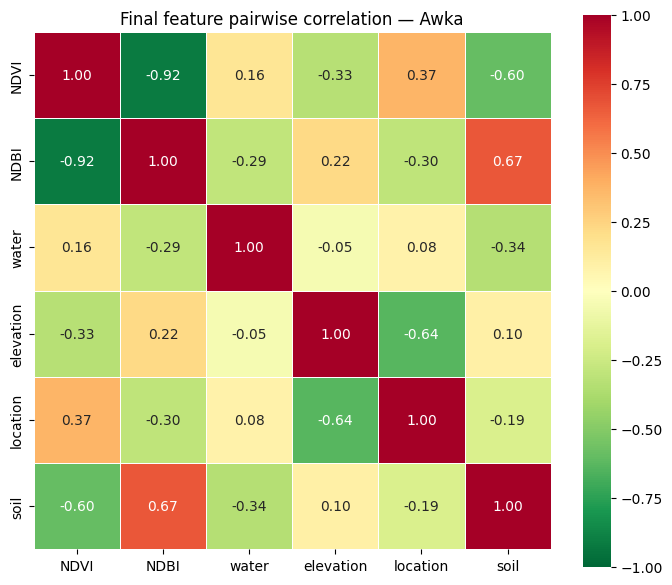

In [54]:
# ── D+E — how alike are the chosen predictors? ───────────────────────────────
# ── correlation heatmap ───────────────────────────────────────────────────────
n = len(final_features)
fig, ax = plt.subplots(figsize=(max(5, n + 1), max(4, n)))
sns.heatmap(df_train[final_features].corr().round(2), annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax)
ax.set_title(f"Final feature pairwise correlation — {current_location}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_feature_correlation_heatmap.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [55]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL G3 — DESIGN MATRICES FROM THE SPATIAL SPLIT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Turns df_train / df_test from CELL G into the X, y and group arrays the
# model cells expect. The block group travels with the rows, so every fold
# stays spatially blocked all the way through tuning.

import numpy as np, pandas as pd
from sklearn.model_selection import GroupKFold

TARGET_COL = LST_COL          # set in CELL C2 PART 1
DROP_COLS  = [TARGET_COL, "x_m", "y_m", "block_x", "block_y", "block_id",
              "block_group", "grid_ref", "fold_name", "longitude", "latitude",
              "lon", "lat", "x", "y"]

if "SELECTED_FEATURES" in globals() and len(SELECTED_FEATURES) > 0:
    FEATURES = list(SELECTED_FEATURES)
    print(f"Features from feature selection : {len(FEATURES)}")
else:
    FEATURES = [c for c in df_train.columns
                if c not in DROP_COLS and pd.api.types.is_numeric_dtype(df_train[c])]
    print(f"Features (all numeric predictors) : {len(FEATURES)}")
    print("  NOTE: no SELECTED_FEATURES found. If you run feature selection,")
    print("        fit it on df_train ONLY, never on DF, or you reintroduce")
    print("        selection leakage (issue h).")

X_train_sp = df_train[FEATURES].copy()
y_train_sp = df_train[TARGET_COL].copy()
X_test_sp  = df_test[FEATURES].copy()
y_test_sp  = df_test[TARGET_COL].copy()
groups     = df_train["block_group"].to_numpy()      # numpy, so positional indexing works
cv_spatial = GroupKFold(n_splits=N_FOLDS)            # a splitter, NOT a list of splits

assert len(np.unique(groups)) == N_FOLDS, (
    f"training set holds {len(np.unique(groups))} groups, expected {N_FOLDS}")
assert not X_train_sp.isna().any().any(), "NaNs in X_train_sp"
assert not X_test_sp.isna().any().any(),  "NaNs in X_test_sp"

print(f"\nTrain : {X_train_sp.shape[0]:,} rows x {X_train_sp.shape[1]} features")
print(f"Test  : {X_test_sp.shape[0]:,} rows  (held-out block group {HOLDOUT_GROUP})")
print(f"Groups: {sorted(np.unique(groups))}")

Features from feature selection : 6

Train : 207,411 rows x 6 features
Test  : 41,121 rows  (held-out block group 2)
Groups: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]


In [56]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL G4 — SPATIAL CV BLOCK DESIGN, OVERLAID ON THE OBSERVED LST
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# WHAT THIS FIGURE SHOWS, in plain English
#   Background : the observed Landsat LST for this city, one cell per pixel.
#   Foreground : the cross-validation blocks, drawn as coloured OUTLINES with
#                no fill, so the temperature underneath stays readable.
#   The point  : a reader can see for themselves that each fold covers a
#                genuinely different thermal neighbourhood — that the held-out
#                block is not just "20 % of the pixels" but a distinct piece
#                of the city. That is the argument for spatial CV, and very
#                few LST/UHI papers actually show it.
#
# WHY THE OVERLAY IS GEOMETRICALLY VALID
#   blocks_out stores x_left / y_bottom in projected metres (UTM 32N), and
#   CELL C2 wrote matching x_m / y_m onto every pixel. Both layers therefore
#   live in the SAME coordinate system, so the blocks land exactly where the
#   pixels are. We deliberately do NOT use the lon/lat rasters from CELL N
#   here — mixing degrees and metres on one axis would shift the grid.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── settings you may tune ────────────────────────────────────────────────────
PANEL_LETTER   = {"Awka": "a", "Nnewi": "b", "Onitsha": "c"}.get(current_location, "a")
SCALEBAR_KM    = 5
PIXEL_M        = 30          # Landsat native resolution — the basemap bin size
LST_CMAP       = "jet"       # "turbo" is the same rainbow but perceptually even;
                             # some reviewers now object to jet specifically
LST_PCT        = (2, 98)     # colour limits, as percentiles — kills outliers
VIEW_MODE      = "roi"       # "roi"    → frame the study area; edge blocks are
                             #            clipped where the grid overshoots it
                             # "blocks" → frame the whole block envelope (the
                             #            old behaviour: lots of empty grid)
SLIVER_FRAC    = 0.05        # a block holding fewer than this share of the
                             # median block's pixels is reported as marginal
FOLD_FILL_ALPHA = 0.00       # 0 = fully transparent fill. Anything above ~0.15
                             # starts tinting the LST underneath and makes the
                             # temperatures unreadable. Leave at 0.
HOLDOUT_EDGE   = "black"
BASE_DIM       = 0.00        # white veil over the LST. Keep at 0 for the published
                             # figure: any veil shifts the displayed colours away
                             # from the colourbar. Raise to ~0.10 only for slides.

# ── how the blocks are separated ─────────────────────────────────────────────
# Instead of a coloured line around every block, the blocks are separated by a
# white GUTTER, so the map reads as 25 discrete tiles. Fold identity is then
# carried entirely by the coloured chip in each tile. This keeps the LST
# surface uninterrupted by 25 competing coloured lines, which is what made the
# earlier version busy.
GUTTER_FRAC    = 0.035       # gutter width as a fraction of one block
FIG_BORDER     = True        # thin black frame around the whole panel
GRIDREF_INK    = "black"     # grid reference text colour (haloed in white)

# ── coordinate labels around the edge ────────────────────────────────────────
# The map has to be drawn in metres, otherwise the squares would not line up
# with the pixels. But metres (282000, 284000 ...) mean nothing to a reader, so
# the edges get labelled in degrees instead, the same way ds.LST_C.plot() does.
SHOW_GRATICULE  = True
GRATICULE_TICKS = 5          # roughly how many labels per side
GRATICULE_LINES = False      # True also draws faint lines across the map
UTM_EPSG        = globals().get("UTM_EPSG", 32632)   # UTM zone 32N, Anambra


# ── fold chip palette ────────────────────────────────────────────────────────
# Saturated hues, chosen so a chip stays distinct sitting on any part of the
# LST ramp. Validated for colour-vision safety: the worst pair (magenta vs
# green) separates by ΔE 6.6 under deuteranopia, which is inside the floor
# band and legal ONLY because every chip also carries its F1–F5 text. Do not
# remove the text labels.
FOLD_COLOURS = ["#E69F00",   # F1 amber
                "#1F6FE0",   # F2 blue
                "#148F45",   # F3 green
                "#56B4E9",   # F4 sky blue
                "#E8177D",   # F5 magenta
                "#8C564B",   # brown  (only if N_FOLDS > 5)
                "#5F5F5F"]   # grey   (only if N_FOLDS > 6)


def label_ink(hex_colour):
    """Black text on light chips, white text on dark chips."""
    r, g, b = tuple(int(hex_colour[i:i + 2], 16) / 255 for i in (1, 3, 5))
    return "black" if (0.299 * r + 0.587 * g + 0.114 * b) > 0.6 else "white"


# ── grid references : letters west to east, numbers north to south ───────────
cols_sorted = sorted(blocks_out["block_x"].unique())
rows_sorted = sorted(blocks_out["block_y"].unique(), reverse=True)
col_letter  = {bx: chr(ord("A") + i) for i, bx in enumerate(cols_sorted)}
row_number  = {by: i + 1 for i, by in enumerate(rows_sorted)}

blocks_out["grid_ref"] = [f"{col_letter[r.block_x]}{row_number[r.block_y]}"
                          for r in blocks_out.itertuples(index=False)]

# ── fold names : the held-out group is TEST, the rest are F1…F5 ──────────────
fold_name, next_fold = {}, 1
for gid in range(N_BLOCK_GROUPS):
    if gid == HOLDOUT_GROUP:
        fold_name[gid] = "TEST"
    else:
        fold_name[gid] = f"F{next_fold}"
        next_fold += 1
blocks_out["fold_name"] = blocks_out["block_group"].map(fold_name)

# colour lookup: held-out block is black, training folds take the palette
fold_colour = {}
_i = 0
for gid in range(N_BLOCK_GROUPS):
    if gid == HOLDOUT_GROUP:
        fold_colour[gid] = HOLDOUT_EDGE
    else:
        fold_colour[gid] = FOLD_COLOURS[_i % len(FOLD_COLOURS)]
        _i += 1

In [57]:
# ── locate the pixel table that carries LST and metre coordinates ────────────
_SRC = None
for _name in ("DF", "df_model", "df_all", "model_df", "df"):
    if _name in globals() and isinstance(globals()[_name], pd.DataFrame):
        if {"x_m", "y_m"}.issubset(globals()[_name].columns):
            _SRC, _SRC_NAME = globals()[_name], _name
            break
if _SRC is None and {"df_train", "df_test"} <= set(globals()):
    _SRC, _SRC_NAME = pd.concat([df_train, df_test], ignore_index=True), "df_train+df_test"
if _SRC is None:
    raise RuntimeError("No pixel table with x_m / y_m found — run CELL C2 PART 1 first.")

_LSTC = next((c for c in ("LST_C", "lst_c", "LST", "lst") if c in _SRC.columns), None)
if _LSTC is None:
    raise KeyError(f"No LST column in {_SRC_NAME}. Columns: {list(_SRC.columns)[:20]}")
print(f"Basemap source : {_SRC_NAME}  ({len(_SRC):,} pixels, LST column '{_LSTC}')")

# ── map extent, snapped to the block grid so pixels and blocks align ─────────
map_x0 = float(blocks_out["x_left"].min())
map_x1 = float(blocks_out["x_left"].max() + BLOCK_SIZE_M)
map_y0 = float(blocks_out["y_bottom"].min())
map_y1 = float(blocks_out["y_bottom"].max() + BLOCK_SIZE_M)
map_w, map_h = map_x1 - map_x0, map_y1 - map_y0

# ── bin the pixels onto a regular grid, so imshow can draw them ──────────────
# The pixels came from GEE on a lon/lat grid; reprojecting to metres leaves
# them very slightly irregular. Binning at the native 30 m puts them back on a
# clean raster without resampling the values — each cell is the mean of the
# pixels that fall inside it, and empty cells (outside the ROI) stay NaN.
nx = max(1, int(round(map_w / PIXEL_M)))
ny = max(1, int(round(map_h / PIXEL_M)))
x_edges = np.linspace(map_x0, map_x1, nx + 1)
y_edges = np.linspace(map_y0, map_y1, ny + 1)

_xy   = _SRC[["x_m", "y_m", _LSTC]].dropna()
sum_h, _, _ = np.histogram2d(_xy["x_m"], _xy["y_m"], bins=[x_edges, y_edges],
                             weights=_xy[_LSTC])
cnt_h, _, _ = np.histogram2d(_xy["x_m"], _xy["y_m"], bins=[x_edges, y_edges])

with np.errstate(invalid="ignore", divide="ignore"):
    lst_grid = np.where(cnt_h > 0, sum_h / cnt_h, np.nan).T   # .T -> (row, col)

vmin, vmax = np.nanpercentile(lst_grid, LST_PCT)
coverage   = 100.0 * np.isfinite(lst_grid).sum() / lst_grid.size
print(f"Basemap grid   : {nx} x {ny} cells at {PIXEL_M} m "
      f"({coverage:.0f} % of the block envelope covered by ROI pixels)")
print(f"LST range      : {vmin:.1f} – {vmax:.1f} °C  "
      f"({LST_PCT[0]}–{LST_PCT[1]}th percentile)")

# ── where the study area actually is, inside the block envelope ──────────────
# CELL G starts the block grid at the ROI's south-west corner and rounds UP to
# whole blocks, so the envelope always overshoots the ROI — by up to one block
# in each direction. Framing the figure on the envelope leaves that overshoot
# as dead white space (often 25–35 % of the panel). We measure the real data
# extent from the binned grid and frame on that instead.
_fin      = np.isfinite(lst_grid)
_fin_cols = np.flatnonzero(_fin.any(axis=0))
_fin_rows = np.flatnonzero(_fin.any(axis=1))
roi_x0, roi_x1 = float(x_edges[_fin_cols[0]]), float(x_edges[_fin_cols[-1] + 1])
roi_y0, roi_y1 = float(y_edges[_fin_rows[0]]), float(y_edges[_fin_rows[-1] + 1])

if VIEW_MODE == "roi":
    view_x0, view_x1, view_y0, view_y1 = roi_x0, roi_x1, roi_y0, roi_y1
else:
    view_x0, view_x1, view_y0, view_y1 = map_x0, map_x1, map_y0, map_y1
view_w, view_h = view_x1 - view_x0, view_y1 - view_y0

over_x = (map_w - (roi_x1 - roi_x0)) / 1000.0
over_y = (map_h - (roi_y1 - roi_y0)) / 1000.0
print(f"Study area     : {(roi_x1-roi_x0)/1000:.1f} x {(roi_y1-roi_y0)/1000:.1f} km"
      f"   block envelope overshoots it by {over_x:.1f} km E-W, {over_y:.1f} km N-S")
print(f"View mode      : '{VIEW_MODE}' — framing "
      f"{'the study area (edge blocks clipped)' if VIEW_MODE == 'roi' else 'the full block envelope'}")

# ── blocks that barely touch the ROI ─────────────────────────────────────────
# These are a figure problem AND a modelling one: a 'block' holding 2 % of a
# normal block's pixels contributes almost nothing to its fold but still counts
# as a block when the folds are balanced. Worth knowing before you defend the
# design in a methods section.
_med    = float(blocks_out["n_pixels"].median())
slivers = blocks_out[blocks_out["n_pixels"] < SLIVER_FRAC * _med]
if len(slivers):
    print(f"\n  ⚠ {len(slivers)} block(s) hold < {SLIVER_FRAC:.0%} of the median "
          f"block's pixels ({_med:,.0f}):")
    for r in slivers.sort_values("n_pixels").itertuples(index=False):
        print(f"      {r.grid_ref}  fold {r.fold_name:<5} {r.n_pixels:>7,} px "
              f"({100*r.n_pixels/_med:.1f} % of median)")
    print("    They are kept in the analysis — this is a heads-up, not a change.")

# room under the map for the coordinate labels, scale bar and north arrow,
# and room on the left for the latitude labels
band_h   = (0.20 if SHOW_GRATICULE else 0.13) * view_h
side_pad = 0.055 * view_w
left_pad = (0.115 if SHOW_GRATICULE else 0.055) * view_w

# ── figure size derived from the framed shape, not hardcoded ─────────────────
# The axes are equal-aspect, so a fixed figsize leaves a dead white band under
# any city whose framed area is not square. Sizing the canvas from the data
# keeps the three city panels consistent when they sit side by side.
FIG_W, LEGEND_IN, TOP_FRAC = 6.3, 0.42, 0.940
AX_L, AX_R = 0.050, 0.870
data_aspect = ((view_h + band_h + 0.025 * view_h) / (view_w + left_pad + side_pad))
ax_w_in  = FIG_W * (AX_R - AX_L)
ax_h_in  = ax_w_in * data_aspect
FIG_H    = (ax_h_in + LEGEND_IN) / TOP_FRAC
AX_B     = LEGEND_IN / FIG_H

Basemap source : DF  (248,532 pixels, LST column 'LST_C')
Basemap grid   : 583 x 583 cells at 30 m (72 % of the block envelope covered by ROI pixels)
LST range      : 29.1 – 39.8 °C  (2–98th percentile)
Study area     : 14.9 x 14.9 km   block envelope overshoots it by 2.6 km E-W, 2.6 km N-S
View mode      : 'roi' — framing the study area (edge blocks clipped)


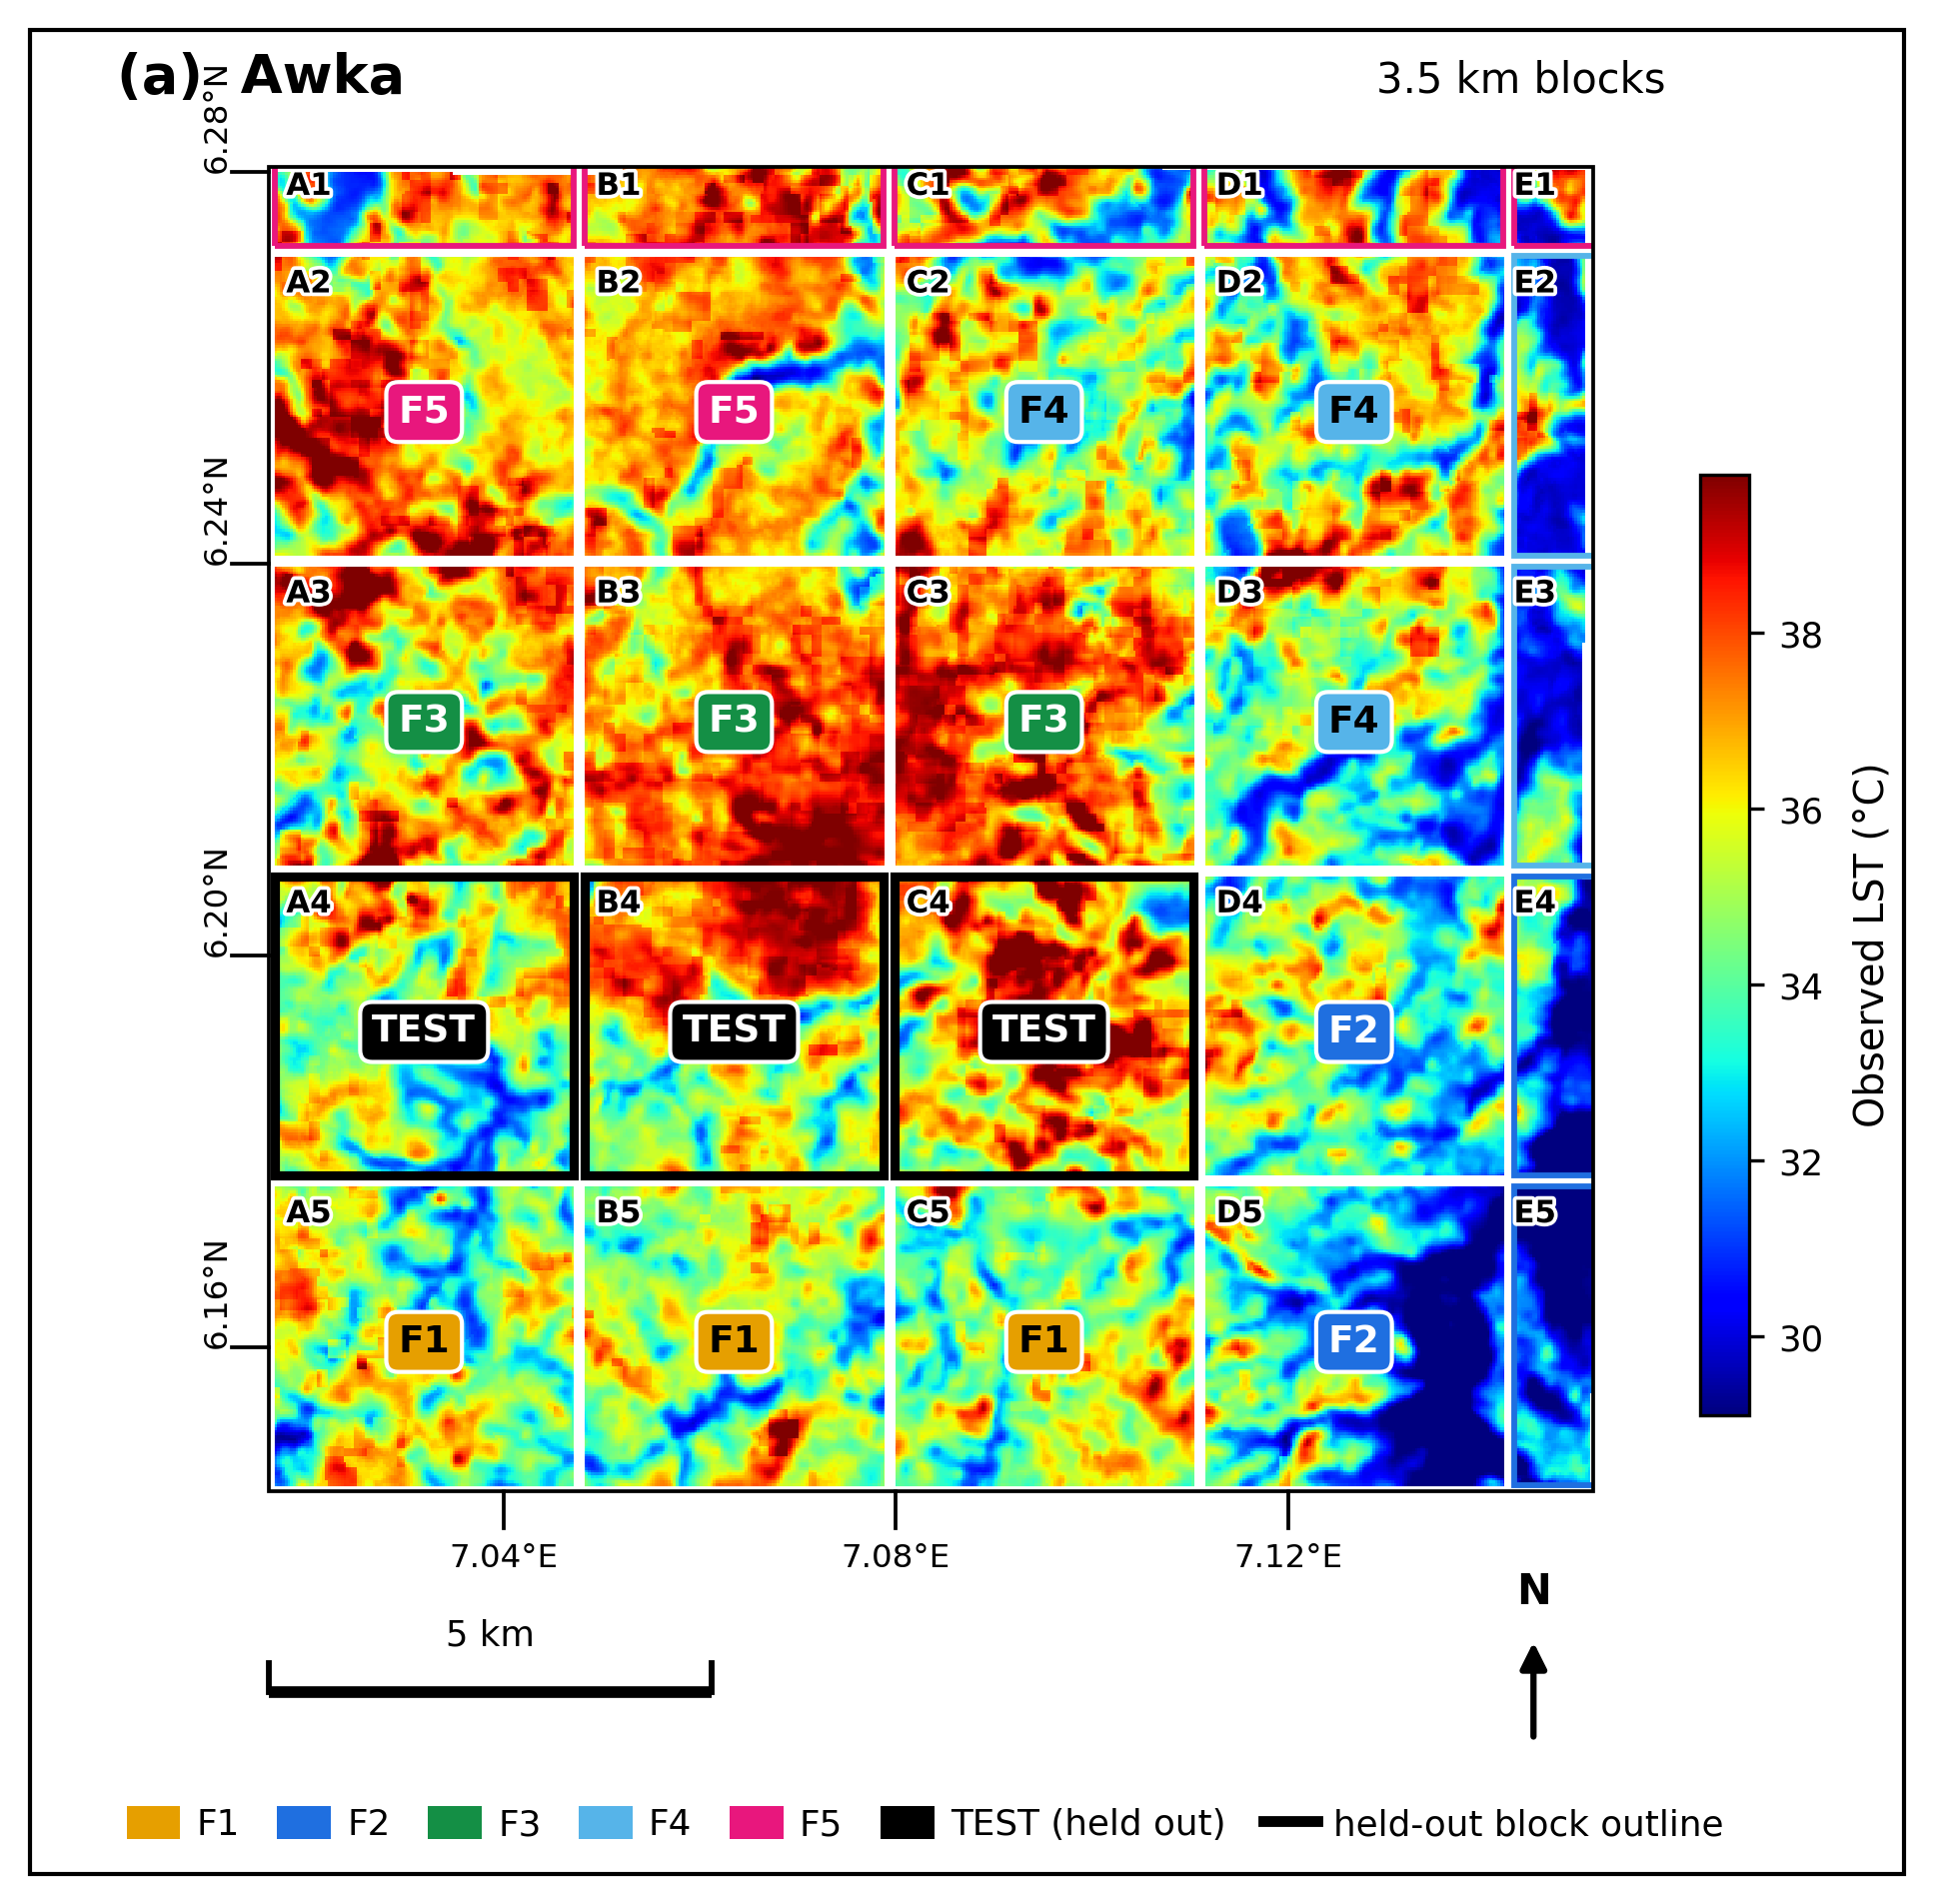

In [58]:
# ── G4 — the figure ─────────────────────────────────────────────────────────
# EVERYTHING that touches the figure lives in THIS ONE CELL. If you split it,
# Colab shows the half-finished figure at the end of the first cell and the
# rest of the furniture never appears. That is what produced the bare version
# with raw metre ticks and no legend.
# ── figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

im = ax.imshow(lst_grid, origin="lower", extent=(map_x0, map_x1, map_y0, map_y1),
               cmap=LST_CMAP, vmin=vmin, vmax=vmax,
               interpolation="none", zorder=1)

# a whisper of white over the raster: the fold outlines read cleanly without
# the temperatures losing their punch
ax.add_patch(Rectangle((map_x0, map_y0), map_w, map_h,
                       facecolor="white", alpha=BASE_DIM,
                       edgecolor="none", zorder=2))

# ── white gutters between blocks ─────────────────────────────────────────────
# Every block is stroked in white. Adjacent blocks share a boundary and both
# stroke it, so the two half-widths meet and the map reads as separate tiles.
# The stroke width is computed from the figure geometry rather than set in
# points, so the gutter stays the same fraction of a block at any figure size.
# Everything is clipped to the study area — without that, a block hanging off
# the ROI edge leaves stray line stubs floating in the empty margin.
pt_per_m   = (ax_w_in * 72.0) / (view_w + left_pad + side_pad)
gutter_m   = GUTTER_FRAC * BLOCK_SIZE_M
gutter_lw  = gutter_m * pt_per_m
inset      = gutter_m / 2.0

view_clip = Rectangle((view_x0, view_y0), view_w, view_h,
                      transform=ax.transData, facecolor="none", edgecolor="none")
ax.add_patch(view_clip)

unlabelled = []
for row in blocks_out.itertuples(index=False):
    col    = fold_colour[row.block_group]
    is_out = bool(getattr(row, "is_holdout", 0))

    gut = Rectangle((row.x_left, row.y_bottom), BLOCK_SIZE_M, BLOCK_SIZE_M,
                    facecolor=col if FOLD_FILL_ALPHA > 0 else "none",
                    alpha=None if FOLD_FILL_ALPHA == 0 else FOLD_FILL_ALPHA,
                    edgecolor="white", linewidth=gutter_lw, zorder=3)
    ax.add_patch(gut)
    gut.set_clip_path(view_clip)

    # ── label the VISIBLE part of the block, not the whole block ────────────
    # In "roi" view an edge block may be a thin strip. Centring its label on
    # the block's true centre would push the text outside the frame, or into
    # its neighbour. We anchor to the block ∩ view rectangle instead.
    vx0, vx1 = max(row.x_left, view_x0), min(row.x_left + BLOCK_SIZE_M, view_x1)
    vy0, vy1 = max(row.y_bottom, view_y0), min(row.y_bottom + BLOCK_SIZE_M, view_y1)
    if vx1 <= vx0 or vy1 <= vy0:
        continue                               # block lies entirely outside
    vw, vh = vx1 - vx0, vy1 - vy0

    # held-out blocks: a heavy black box just inside the gutter
    if is_out:
        hb = Rectangle((row.x_left + inset, row.y_bottom + inset),
                       BLOCK_SIZE_M - 2 * inset, BLOCK_SIZE_M - 2 * inset,
                       facecolor="none", edgecolor=HOLDOUT_EDGE,
                       linewidth=2.2, zorder=6)
        ax.add_patch(hb)
        hb.set_clip_path(view_clip)

    # grid reference, upper-left — black ink with a thin white halo, so it
    # reads as black text but survives the dark red end of the ramp
    if vw > 0.18 * BLOCK_SIZE_M and vh > 0.12 * BLOCK_SIZE_M:
        ax.text(vx0 + 0.055 * vw, vy1 - 0.06 * vh, row.grid_ref,
                ha="left", va="top", fontsize=7.4, fontweight="bold",
                color=GRIDREF_INK, zorder=7,
                path_effects=[pe.withStroke(linewidth=1.8, foreground="white")])

    # fold chip, centred — with no coloured outline on the tile any more, this
    # chip is the ONLY carrier of fold identity, so a block too thin to hold
    # one instead gets its tile edge drawn in the fold colour.
    if vw > 0.40 * BLOCK_SIZE_M and vh > 0.30 * BLOCK_SIZE_M:
        ax.text(vx0 + 0.50 * vw, vy0 + 0.48 * vh, row.fold_name,
                ha="center", va="center", fontsize=9.0, fontweight="bold",
                color=label_ink(col) if col != "black" else "white", zorder=7,
                bbox=dict(boxstyle="round,pad=0.32", facecolor=col,
                          edgecolor="white", linewidth=1.0, alpha=1.0))
    elif not is_out:
        unlabelled.append(f"{row.grid_ref} ({row.fold_name})")
        eb = Rectangle((row.x_left + inset, row.y_bottom + inset),
                       BLOCK_SIZE_M - 2 * inset, BLOCK_SIZE_M - 2 * inset,
                       facecolor="none", edgecolor=col, linewidth=1.4, zorder=6)
        ax.add_patch(eb)
        eb.set_clip_path(view_clip)

# ── map limits ───────────────────────────────────────────────────────────────
ax.set_xlim(view_x0 - left_pad, view_x1 + side_pad)
ax.set_ylim(view_y0 - band_h,   view_y1 + 0.025 * view_h)
ax.set_aspect("equal", adjustable="box")
ax.set_axis_off()

# ── coordinate labels around the map edge ────────────────────────────────────
# Round degree values are picked first, then converted back into metres, so
# each tick sits exactly where that meridian or parallel really is.
if SHOW_GRATICULE:
    from pyproj import Transformer

    metres_to_degrees = Transformer.from_crs(f"EPSG:{UTM_EPSG}", "EPSG:4326", always_xy=True)
    degrees_to_metres = Transformer.from_crs("EPSG:4326", f"EPSG:{UTM_EPSG}", always_xy=True)

    def round_steps(low, high, about_how_many):
        """Pick round numbers (0.02, 0.05, 0.1 ...) spanning low to high."""
        rough = (high - low) / max(about_how_many, 1)
        size  = 10.0 ** np.floor(np.log10(rough))
        step  = size
        for multiple in (1, 2, 2.5, 4, 5, 10):
            step = multiple * size
            if rough <= step:
                break
        first = np.ceil(low / step) * step
        return np.arange(first, high + step * 1e-6, step), step

    west_lon,  south_lat = metres_to_degrees.transform(view_x0, view_y0)
    east_lon,  north_lat = metres_to_degrees.transform(view_x1, view_y1)

    lon_ticks, lon_step = round_steps(west_lon,  east_lon,  GRATICULE_TICKS)
    lat_ticks, lat_step = round_steps(south_lat, north_lat, GRATICULE_TICKS)
    lon_places = max(0, int(-np.floor(np.log10(lon_step))))
    lat_places = max(0, int(-np.floor(np.log10(lat_step))))

    tick_down = 0.028 * view_h
    tick_left = 0.028 * view_w

    # longitude along the bottom
    for lon in lon_ticks:
        x_here, _ = degrees_to_metres.transform(lon, south_lat)
        if not (view_x0 <= x_here <= view_x1):
            continue
        ax.plot([x_here, x_here], [view_y0, view_y0 - tick_down],
                color="black", lw=0.9, zorder=9, clip_on=False)
        ax.text(x_here, view_y0 - tick_down * 1.4, f"{lon:.{lon_places}f}\u00b0E",
                ha="center", va="top", fontsize=7.8, color="black", zorder=9)
        if GRATICULE_LINES:
            ax.plot([x_here, x_here], [view_y0, view_y1], color="white",
                    lw=0.5, ls=":", alpha=0.5, zorder=5)

    # latitude up the left-hand side
    for lat in lat_ticks:
        _, y_here = degrees_to_metres.transform(west_lon, lat)
        if not (view_y0 <= y_here <= view_y1):
            continue
        ax.plot([view_x0, view_x0 - tick_left], [y_here, y_here],
                color="black", lw=0.9, zorder=9, clip_on=False)
        ax.text(view_x0 - tick_left * 1.4, y_here, f"{lat:.{lat_places}f}\u00b0N",
                ha="center", va="bottom", fontsize=7.8, color="black",
                rotation=90, zorder=9)
        if GRATICULE_LINES:
            ax.plot([view_x0, view_x1], [y_here, y_here], color="white",
                    lw=0.5, ls=":", alpha=0.5, zorder=5)

    # a thin box around the map, so the ticks have something to sit against
    ax.add_patch(Rectangle((view_x0, view_y0), view_w, view_h, facecolor="none",
                           edgecolor="black", lw=0.9, zorder=9))

# ── scale bar : inside the blank band, left, label above the bar ─────────────
bar_len = SCALEBAR_KM * 1000
bar_x   = view_x0
bar_y   = view_y0 - 0.76 * band_h

ax.plot([bar_x, bar_x + bar_len], [bar_y, bar_y],
        color="black", lw=2.8, solid_capstyle="butt", zorder=8)
for tick_x in (bar_x, bar_x + bar_len):
    ax.plot([tick_x, tick_x], [bar_y, bar_y + 0.11 * band_h],
            color="black", lw=1.4, zorder=8)
ax.text(bar_x + bar_len / 2, bar_y + 0.15 * band_h, f"{SCALEBAR_KM} km",
        ha="center", va="bottom", fontsize=8.5, color="black", zorder=8)

# ── north arrow : inside the blank band, right ───────────────────────────────
arrow_x = view_x1 - 0.045 * view_w
arrow_y = view_y0 - 0.96 * band_h
ax.annotate("", xy=(arrow_x, arrow_y + 0.42 * band_h), xytext=(arrow_x, arrow_y),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5,
                            mutation_scale=13), zorder=8)
ax.text(arrow_x, arrow_y + 0.50 * band_h, "N", ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="black", zorder=8)

# ── titles ───────────────────────────────────────────────────────────────────
ax.set_title(f"({PANEL_LETTER})  {current_location}", loc="left",
             fontsize=13, fontweight="bold", pad=10, color="black")
ax.set_title(f"{BLOCK_SIZE_M/1000:.1f} km blocks", loc="right",
             fontsize=10, color="black", pad=10)

# ── reserved space, then the LST colourbar and the fold legend ───────────────
fig.subplots_adjust(bottom=AX_B, top=TOP_FRAC, left=AX_L, right=AX_R)

# slim vertical colourbar on the right of the map — the LST is real data now,
# so it needs a scale
_cb_h = 0.58 * (TOP_FRAC - AX_B)
cax = fig.add_axes([AX_R + 0.018, AX_B + 0.21 * (TOP_FRAC - AX_B), 0.026, _cb_h])
cb  = fig.colorbar(ScalarMappable(norm=Normalize(vmin, vmax), cmap=LST_CMAP),
                   cax=cax)
cb.set_label("Observed LST (°C)", fontsize=9.5, labelpad=7)
cb.ax.tick_params(labelsize=8.5)
cb.outline.set_linewidth(0.8)
cb.outline.set_edgecolor("black")

# fold legend — one chip per fold, matching the in-map chips exactly, laid out
# as ONE row so it reads left to right in fold order instead of wrapping into
# columns the eye has to reassemble.
train_gids = [g for g in range(N_BLOCK_GROUPS) if g != HOLDOUT_GROUP]
order      = train_gids + [HOLDOUT_GROUP]
handles    = [Patch(facecolor=fold_colour[g], edgecolor="none",
                    label=fold_name[g] + (" (held out)" if g == HOLDOUT_GROUP else ""))
              for g in order]
handles.append(Line2D([0], [0], color=HOLDOUT_EDGE, lw=2.6,
                      label="held-out block outline"))

fig.legend(handles=handles, loc="lower left", ncol=len(handles), frameon=False,
           fontsize=8.6, handlelength=1.5, handleheight=1.0,
           columnspacing=1.05, handletextpad=0.45,
           bbox_to_anchor=(AX_L - 0.012, 0.004))

# thin frame around the whole panel, the way journal figure panels are set
if FIG_BORDER:
    fig.add_artist(Rectangle((0.004, 0.004), 0.992, 0.992,
                             transform=fig.transFigure, fill=False,
                             edgecolor="black", linewidth=1.0, zorder=20))

fig.savefig(f"{OUT_DIR}/F04b_{current_location}_block_design.png",
            dpi=300, bbox_inches="tight", pad_inches=0.05, facecolor="white")
plt.show()

In [59]:
# ── reference table, so the text can cite blocks by name ─────────────────────
ref_table = (blocks_out[["grid_ref", "fold_name", "block_group", "n_pixels"]]
             .sort_values(["fold_name", "grid_ref"])
             .reset_index(drop=True))
ref_table.to_csv(f"{OUT_DIR}/T_block_reference_{current_location}.csv", index=False)

print(f"\nBlocks: {len(ref_table)}   held-out fold: TEST (group {HOLDOUT_GROUP})")
print(ref_table.groupby("fold_name")
               .agg(blocks=("grid_ref", "count"),
                    pixels=("n_pixels", "sum"),
                    members=("grid_ref", lambda s: ", ".join(sorted(s)))))
print(f"\nSaved -> {OUT_DIR}/F04b_{current_location}_block_design.png")
print(f"Saved -> {OUT_DIR}/T_block_reference_{current_location}.csv")

save_report_table(
    ref_table.rename(columns={"grid_ref": "Square", "fold_name": "Fold",
                              "block_group": "Band", "n_pixels": "Pixels"}),
    "block_design",
    caption=(f"How {current_location} was cut up for cross-validation. Each square "
             f"is {BLOCK_SIZE_M/1000:.1f} km across; squares are grouped into bands, "
             f"and one band is held back for testing."),
)


Blocks: 25   held-out fold: TEST (group 2)
           blocks  pixels                     members
fold_name                                            
F1              3   40990                  A5, B5, C5
F2              4   34888              D4, D5, E4, E5
F3              3   41146                  A3, B3, C3
F4              5   47823          C2, D2, D3, E2, E3
F5              7   42564  A1, A2, B1, B2, C1, D1, E1
TEST            3   41121                  A4, B4, C4

Saved -> /content/drive/MyDrive/Anambra_lst_modelling/Awka_results/F04b_Awka_block_design.png
Saved -> /content/drive/MyDrive/Anambra_lst_modelling/Awka_results/T_block_reference_Awka.csv

Table 4. How Awka was cut up for cross-validation. Each square is 3.5 km across; squares are grouped into bands, and one band is held back for testing.


,Square,Fold,Band,Pixels
0,A5,F1,0,13599
1,B5,F1,0,13672
2,C5,F1,0,13719
3,D4,F2,1,13747
4,D5,F2,1,13747
5,E4,F2,1,3732
6,E5,F2,1,3662
7,A3,F3,3,13691
8,B3,F3,3,13721
9,C3,F3,3,13734


saved -> /content/drive/MyDrive/Anambra_lst_modelling/_tables/Awka_block_design.csv


,Square,Fold,Band,Pixels
0,A5,F1,0,13599
1,B5,F1,0,13672
2,C5,F1,0,13719
3,D4,F2,1,13747
4,D5,F2,1,13747
5,E4,F2,1,3732
6,E5,F2,1,3662
7,A3,F3,3,13691
8,B3,F3,3,13721
9,C3,F3,3,13734


In [60]:
# ── H — the three models and what we will try for each ───────────────────────
# XGBoost, RandomForest and LightGBM. All three are tree models, so they can
# handle the fact that temperature does not rise in a straight line with
# built-up cover.
#
# Important: all three get the SAME budget. If you search harder for one model
# than another, "which model is best" really just means "which one did I try
# harder with".

N_TUNE     = 40_000   # rows used while searching for good settings
N_ITER     = 20       # how many different settings to try, per model
SEED       = 42

SEARCH_JOBS = -1      # run the search across all cores ...
MODEL_JOBS  = 1       # ... and keep each model single-threaded, or they fight

MODELS_TO_TRY = {
    "XGBRegressor": (
        XGBRegressor(random_state=SEED, tree_method="hist"),
        {
            "n_estimators"    : [100, 200, 300, 500],
            "max_depth"       : [3, 4, 6, 8],
            "learning_rate"   : [0.01, 0.05, 0.1],
            "subsample"       : [0.6, 0.7, 0.9],
            "colsample_bytree": [0.6, 0.7, 0.9],
            "reg_lambda"      : [1, 5, 10],
            "reg_alpha"       : [0, 0.5, 1],
            "gamma"           : [0, 0.5, 1],
        },
    ),
    "RandomForestRegressor": (
        RandomForestRegressor(random_state=SEED),
        {
            "n_estimators"     : [200, 300, 500],
            "max_depth"        : [8, 12, 16, None],
            "max_features"     : ["sqrt", 0.3, 0.5],
            "min_samples_leaf" : [1, 2, 4, 8],
            "min_samples_split": [2, 5, 10],
        },
    ),
    "LGBMRegressor": (
        LGBMRegressor(random_state=SEED, verbose=-1),
        {
            "n_estimators"    : [100, 200, 300, 500],
            "max_depth"       : [3, 5, 7, -1],
            "learning_rate"   : [0.01, 0.05, 0.1],
            "num_leaves"      : [31, 63, 127],
            "subsample"       : [0.6, 0.8, 1.0],
            "subsample_freq"  : [1],   # without this LightGBM ignores subsample
            "colsample_bytree": [0.6, 0.8, 1.0],
            "reg_alpha"       : [0, 0.5, 1],
            "reg_lambda"      : [0, 0.5, 1],
        },
    ),
}

# kept under the old name too, because CELL I and I2 look for it
FIXED_MODELS = MODELS_TO_TRY

print(f"Models      : {', '.join(MODELS_TO_TRY)}")
print(f"Same budget : {N_ITER} tries on {min(N_TUNE, len(X_train_sp)):,} rows each")

Models      : XGBRegressor, RandomForestRegressor, LGBMRegressor
Same budget : 20 tries on 40,000 rows each


In [61]:
# ── H — helper: take a sample that covers every band ─────────────────────────
# If we just took a random sample for the search, one band could end up with
# almost no rows and its fold would be useless. So we take an equal share from
# each band instead.

import gc

def sample_from_every_band(how_many, band_of_row, seed=SEED):
    """Pick about `how_many` rows, spread evenly across the bands."""
    rng      = np.random.RandomState(seed)
    bands    = np.unique(band_of_row)
    per_band = max(1, int(how_many // len(bands)))

    picked = []
    for band in bands:
        rows_in_band = np.flatnonzero(band_of_row == band)
        take = min(per_band, len(rows_in_band))
        picked.append(rng.choice(rows_in_band, take, replace=False))
    return np.sort(np.concatenate(picked))


# use the folds CELL G5 built, so tuning and scoring use the same map
if "CV_SPLITS" in globals() and len(CV_SPLITS) == N_FOLDS:
    folds_to_use = CV_SPLITS
    print(f"Using the {N_FOLDS} buffered folds from CELL G5.")
else:
    folds_to_use = list(GroupKFold(n_splits=N_FOLDS).split(X_train_sp, groups=groups))
    print(f"CELL G5 folds not found — rebuilt {N_FOLDS} plain blocked folds.")

Using the 5 buffered folds from CELL G5.


In [ ]:
# ── H — search for good settings, then score them properly ───────────────────
# Two steps per model:
#   1. try N_ITER different settings on a sample, keep the best
#   2. score those settings on the FULL folds, and keep the predictions each
#      fold made for the rows it did NOT train on ("out of fold"). CELL M needs
#      those, and they cost nothing extra here.

print(f"\n=== TUNING — {current_location} ===\n")

tuning_results = []   # (name, cv score, fitted model, best settings)
FOLD_ROWS      = []   # one row per model per fold, for the CSV in CELL Z
OOF_PRED       = {}   # model name -> prediction for every training row

for model_name, (blank_model, settings_to_try) in MODELS_TO_TRY.items():

    # --- step 1: search on a sample ---
    sample_rows = sample_from_every_band(min(N_TUNE, len(X_train_sp)), groups)
    X_sample    = X_train_sp.iloc[sample_rows]
    y_sample    = y_train_sp.iloc[sample_rows]
    bands_sample = groups[sample_rows]

    print(f"  {model_name}  (sample of {len(sample_rows):,}, {N_ITER} tries)")
    gc.collect()

    search = RandomizedSearchCV(
        estimator           = clone(blank_model).set_params(n_jobs=MODEL_JOBS),
        param_distributions = settings_to_try,
        n_iter              = N_ITER,
        cv                  = GroupKFold(n_splits=N_FOLDS),
        scoring             = "r2",
        n_jobs              = SEARCH_JOBS,
        random_state        = SEED,
        refit               = False,     # we refit ourselves, on everything
        error_score         = "raise",
    )
    search.fit(X_sample, y_sample, groups=bands_sample)
    best_settings = dict(search.best_params_)
    print(f"     best on the sample : R2 = {search.best_score_:.4f}")

    del X_sample, y_sample, bands_sample, sample_rows, search
    gc.collect()

    # --- step 2: score on the full folds, and save out-of-fold predictions ---
    oof_prediction = np.full(len(X_train_sp), np.nan)

    for fold_number, (train_rows, val_rows) in enumerate(folds_to_use, start=1):
        model = clone(blank_model).set_params(**best_settings, n_jobs=-1)
        model.fit(X_train_sp.iloc[train_rows], y_train_sp.iloc[train_rows])

        val_prediction   = model.predict(X_train_sp.iloc[val_rows])
        train_prediction = model.predict(X_train_sp.iloc[train_rows])
        oof_prediction[val_rows] = val_prediction

        FOLD_ROWS.append({
            "city"     : current_location,
            "model"    : model_name,
            "fold"     : fold_number,
            "band"     : ";".join(str(b) for b in sorted(np.unique(groups[val_rows]))),
            "n_train"  : int(len(train_rows)),
            "n_val"    : int(len(val_rows)),
            "train_r2" : round(float(r2_score(y_train_sp.iloc[train_rows], train_prediction)), 4),
            "val_r2"   : round(float(r2_score(y_train_sp.iloc[val_rows], val_prediction)), 4),
            "val_rmse" : round(float(np.sqrt(mean_squared_error(y_train_sp.iloc[val_rows], val_prediction))), 3),
            "val_mae"  : round(float(mean_absolute_error(y_train_sp.iloc[val_rows], val_prediction)), 3),
        })
        del model, val_prediction, train_prediction
        gc.collect()

    # with cv_only buffering some rows sit in the gap for every fold, so they
    # never get an out-of-fold prediction. That is fine — we just note it.
    has_prediction = ~np.isnan(oof_prediction)
    OOF_PRED[model_name] = oof_prediction

    fold_scores = np.array([r["val_r2"] for r in FOLD_ROWS if r["model"] == model_name])
    cv_score    = float(fold_scores.mean())
    print(f"     across the folds   : R2 = {cv_score:.4f} +/- {fold_scores.std():.4f}")
    print(f"     out-of-fold predictions for {has_prediction.sum():,} of "
          f"{len(oof_prediction):,} training rows")

    # --- refit on everything, so all three models see identical data ---
    final_model = clone(blank_model).set_params(**best_settings, n_jobs=-1)
    final_model.fit(X_train_sp, y_train_sp)
    print(f"     refitted on all {len(X_train_sp):,} training rows\n")

    tuning_results.append((model_name, cv_score, final_model, best_settings))
    gc.collect()


=== TUNING — Awka ===

  XGBRegressor  (sample of 40,000, 20 tries)
     best on the sample : R2 = 0.4764
     across the folds   : R2 = 0.3056 +/- 0.2571
     out-of-fold predictions for 207,411 of 207,411 training rows
     refitted on all 207,411 training rows

  RandomForestRegressor  (sample of 40,000, 20 tries)


In [ ]:
# ── H — rank them and hand the models on ─────────────────────────────────────

tuning_results.sort(key=lambda row: row[1], reverse=True)

print("=" * 60)
print(f"  RANKING — cross-validation R2 — {current_location}")
print("=" * 60)
for place, (name, score, _model, _settings) in enumerate(tuning_results, 1):
    print(f"  {place}. {name:<24}  R2 = {score:.4f}")

FOLD_SCORES = pd.DataFrame(FOLD_ROWS)

def result_for(name):
    return next(row for row in tuning_results if row[0] == name)

xgb_model,  xgb_cv_r2  = result_for("XGBRegressor")[2],          result_for("XGBRegressor")[1]
rf_model,   rf_cv_r2   = result_for("RandomForestRegressor")[2], result_for("RandomForestRegressor")[1]
lgbm_model, lgbm_cv_r2 = result_for("LGBMRegressor")[2],         result_for("LGBMRegressor")[1]

best_name_global  = tuning_results[0][0]
best_cv_r2_global = tuning_results[0][1]
best_model_global = tuning_results[0][2]

BEST_PARAMS = {name: settings for name, _s, _m, settings in tuning_results}
CV_R2       = {name: score    for name, score, _m, _s in tuning_results}

if "CONFIG" in globals():
    CONFIG["tuning_budget"] = {"n_tune": N_TUNE, "n_iter": N_ITER, "same_for_all": True}
    CONFIG["cv_r2"]         = CV_R2
    CONFIG["best_params"]   = BEST_PARAMS
    CONFIG["best_model"]    = best_name_global
    if "save_config" in globals():
        save_config()

print(f"\n  Best: {best_name_global}  (R2 = {best_cv_r2_global:.4f})")
print("=" * 60)

In [ ]:
# ── I — score the models on the band we held back ────────────────────────────
# The models are already fitted by CELL H, so we do NOT refit them here.
#
# We report two numbers per model:
#   BLOCKED  the held-back band. This is the honest one, and the one to quote.
#   NAIVE    a plain random 80/20 split. Neighbouring pixels are 30 m apart and
#            nearly identical, so most test pixels have a near-twin in training.
#            This number is too good on purpose — it shows what you would have
#            reported if you had not blocked at all.

RUN_NAIVE_BASELINE = True    # set False if you are short on time

# the whole map again, rebuilt from the split so rows and columns match
df_full = pd.concat([df_train, df_test], ignore_index=True)


def score_model(fitted_model, X, y, label):
    """Score a model that has ALREADY been fitted."""
    prediction = fitted_model.predict(X)
    scores = {
        "r2"   : float(r2_score(y, prediction)),
        "rmse" : float(np.sqrt(mean_squared_error(y, prediction))),
        "mae"  : float(mean_absolute_error(y, prediction)),
        "bias" : float((prediction - np.asarray(y)).mean()),
        "y_pred": prediction,
    }
    print(f"  {label:<28}  R2={scores['r2']:6.4f}  RMSE={scores['rmse']:6.3f}  "
          f"MAE={scores['mae']:6.3f}  bias={scores['bias']:+6.3f}")
    return scores


print(f"\n=== HELD-BACK BAND — {current_location} ===")
print(f"  band {HOLDOUT_GROUP}, {len(X_test_sp):,} pixels, never used in training or tuning")
xgb_ho  = score_model(xgb_model,  X_test_sp, y_test_sp, "XGBoost")
rf_ho   = score_model(rf_model,   X_test_sp, y_test_sp, "RandomForest")
lgbm_ho = score_model(lgbm_model, X_test_sp, y_test_sp, "LightGBM")

In [ ]:
# ── I — the naive random split, for comparison only ──────────────────────────

naive = {}
if RUN_NAIVE_BASELINE:
    print(f"\n=== PLAIN RANDOM 80/20 (too good on purpose) ===")
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
        df_full[FEATURES], df_full[TARGET_COL], test_size=0.2, random_state=SEED)

    for name in ("XGBRegressor", "RandomForestRegressor", "LGBMRegressor"):
        model = clone(MODELS_TO_TRY[name][0]).set_params(**BEST_PARAMS[name], n_jobs=-1)
        model.fit(Xn_tr, yn_tr)
        naive[name] = score_model(model, Xn_te, yn_te, name.replace("Regressor", ""))
        del model
        gc.collect()

    del Xn_tr, Xn_te, yn_tr, yn_te
    gc.collect()
else:
    naive = {n: {"r2": np.nan, "rmse": np.nan, "mae": np.nan, "bias": np.nan}
             for n in MODELS_TO_TRY}

In [ ]:
# ── I — the comparison table ─────────────────────────────────────────────────

best_overall = max(CV_R2, key=CV_R2.get)

MODELS  = {"XGBRegressor": xgb_model,
           "RandomForestRegressor": rf_model,
           "LGBMRegressor": lgbm_model}
HOLDOUT = {"XGBRegressor": xgb_ho,
           "RandomForestRegressor": rf_ho,
           "LGBMRegressor": lgbm_ho}
best_model = MODELS[best_overall]

print(f"\n{'='*84}")
print(f"  THREE MODELS — {current_location}")
print(f"{'='*84}")
print(f"  {'Model':<22}{'CV R2':>8}{'Block R2':>10}{'Block RMSE':>12}"
      f"{'Block MAE':>11}{'Naive R2':>10}{'Too good by':>12}")
print(f"  {'-'*82}")
for name, short in [("XGBRegressor", "XGBoost"),
                    ("RandomForestRegressor", "RandomForest"),
                    ("LGBMRegressor", "LightGBM")]:
    blocked, plain = HOLDOUT[name], naive[name]
    too_good_by = plain["r2"] - blocked["r2"]
    print(f"  {short:<22}{CV_R2[name]:>8.4f}{blocked['r2']:>10.4f}{blocked['rmse']:>12.3f}"
          f"{blocked['mae']:>11.3f}{plain['r2']:>10.4f}{too_good_by:>+12.4f}")
print(f"{'='*84}")
print(f"  Best (cross-validation): {best_overall}  R2 = {CV_R2[best_overall]:.4f}")
print(f"\n  'Too good by' is the naive score minus the blocked score. A gap of")
print(f"  0.10 to 0.20 is what you expect when nearby pixels are similar, and")
print(f"  it is why the blocked number is the one that goes in the abstract.")

comparison_table = pd.DataFrame([{
    "Model"                 : short,
    "CV R2"                 : CV_R2[name],
    "Held-back R2"          : HOLDOUT[name]["r2"],
    "Held-back RMSE (degC)" : HOLDOUT[name]["rmse"],
    "Held-back MAE (degC)"  : HOLDOUT[name]["mae"],
    "Held-back bias (degC)" : HOLDOUT[name]["bias"],
    "Naive R2"              : naive[name]["r2"],
    "Too good by"           : naive[name]["r2"] - HOLDOUT[name]["r2"],
} for name, short in [("XGBRegressor", "XGBoost"),
                      ("RandomForestRegressor", "RandomForest"),
                      ("LGBMRegressor", "LightGBM")]])

save_report_table(
    comparison_table, "model_comparison", decimals=3,
    caption=(f"Model performance for {current_location}. 'Held-back' is the "
             f"spatially separated band and is the honest figure. 'Naive' is a "
             f"plain random 80/20 split, shown only to demonstrate how much "
             f"spatial autocorrelation inflates it."),
)

if "CONFIG" in globals():
    CONFIG["blocked_holdout"] = {k: {m: round(v[m], 4) for m in ("r2","rmse","mae","bias")}
                                 for k, v in HOLDOUT.items()}
    CONFIG["naive_holdout"]   = {k: round(v["r2"], 4) for k, v in naive.items()}
    if "save_config" in globals():
        save_config()

In [ ]:
# ── I — observed against predicted, for the best model ───────────────────────

fig, ax = plt.subplots(figsize=(6, 6))
best_prediction = HOLDOUT[best_overall]["y_pred"]

ax.scatter(y_test_sp, best_prediction, s=3, alpha=0.15, edgecolors="none")

low  = min(np.min(y_test_sp), best_prediction.min())
high = max(np.max(y_test_sp), best_prediction.max())
ax.plot([low, high], [low, high], "k--", lw=1)      # the perfect-prediction line
ax.set_xlim(low, high)
ax.set_ylim(low, high)

ax.set_xlabel("Observed LST (degC)")
ax.set_ylabel("Predicted LST (degC)")
ax.set_title(f"Held-back band — {best_overall.replace('Regressor','')} | {current_location}\n"
             f"R2 = {HOLDOUT[best_overall]['r2']:.3f}, "
             f"RMSE = {HOLDOUT[best_overall]['rmse']:.2f} degC")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/06_holdout_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ── I2 — hold out each band in turn ──────────────────────────────────────────
# CELL G held back ONE band, picked by "whichever band has the most typical
# number of pixels". Fair rule, but still one pick. If that band happens to sit
# over the hot middle of the city, the score came from the hardest slice of the
# map and somebody will ask what a different band would have given.
#
# So: every band takes a turn being held back. You then report a range instead
# of a single number.
#
# ONE THING TO SAY IN THE METHODS
#   The settings come from CELL H, which chose them using the original training
#   set. So on five of the six turns those settings had already seen the band
#   being tested. The effect is small, but it is real. Call these six numbers a
#   check on whether the choice of band mattered, not six separate results.

ROTATE_MODELS = [best_overall]     # use list(MODELS_TO_TRY) to do all three

if "df_full" not in globals():
    df_full = pd.concat([df_train, df_test], ignore_index=True)
assert "block_group" in df_full.columns, "block_group missing — run CELL G first."

all_bands = sorted(df_full["block_group"].unique().tolist())

print(f"\n=== EACH BAND HELD OUT IN TURN — {current_location} ===")
print(f"  Bands  : {len(all_bands)}")
print(f"  Models : {', '.join(ROTATE_MODELS)}")
print(f"  Fits   : {len(all_bands) * len(ROTATE_MODELS)}")
print(f"  CELL G's original pick was band {HOLDOUT_GROUP}\n")

# what each band actually contains — this is the context for the scores
band_facts = (df_full.groupby("block_group")
                     .agg(n_pixels=(TARGET_COL, "size"),
                          lst_mean=(TARGET_COL, "mean"),
                          lst_spread=(TARGET_COL, "std"))
                     .round(3))

In [ ]:
# ── I2 — do the rotation ─────────────────────────────────────────────────────

rotation_rows = []

for model_name in ROTATE_MODELS:
    blank_model = MODELS_TO_TRY[model_name][0]

    for band in all_bands:
        is_test  = df_full["block_group"] == band
        is_train = ~is_test

        model = clone(blank_model).set_params(**BEST_PARAMS[model_name], n_jobs=-1)
        model.fit(df_full.loc[is_train, FEATURES], df_full.loc[is_train, TARGET_COL])

        prediction = model.predict(df_full.loc[is_test, FEATURES])
        observed   = df_full.loc[is_test, TARGET_COL].to_numpy(float)

        rotation_rows.append({
            "city"        : current_location,
            "model"       : model_name,
            "band"        : int(band),
            "was_the_pick": int(band == HOLDOUT_GROUP),
            "n_test"      : int(is_test.sum()),
            "n_train"     : int(is_train.sum()),
            "band_mean"   : float(band_facts.loc[band, "lst_mean"]),
            "band_spread" : float(band_facts.loc[band, "lst_spread"]),
            "r2"          : round(float(r2_score(observed, prediction)), 4),
            "rmse"        : round(float(np.sqrt(mean_squared_error(observed, prediction))), 3),
            "mae"         : round(float(mean_absolute_error(observed, prediction)), 3),
            "bias"        : round(float((prediction - observed).mean()), 3),
        })

        marker = "  <- CELL G's pick" if band == HOLDOUT_GROUP else ""
        row = rotation_rows[-1]
        print(f"  band {band}  R2={row['r2']:6.4f}  RMSE={row['rmse']:5.2f}  "
              f"mean {row['band_mean']:5.2f} +/- {row['band_spread']:4.2f} degC{marker}")

        del model, prediction
        gc.collect()

ROTATION = pd.DataFrame(rotation_rows)

In [ ]:
# ── I2 — what to actually write in the paper ─────────────────────────────────

print(f"\n{'='*72}")
for model_name in ROTATE_MODELS:
    rows = ROTATION[ROTATION["model"] == model_name]
    the_pick = float(rows.loc[rows["was_the_pick"] == 1, "r2"].iloc[0])

    print(f"  {model_name} — {current_location}")
    print(f"    reported band  : R2 = {the_pick:.4f}")
    print(f"    all {len(rows)} bands   : R2 = {rows['r2'].mean():.4f} +/- {rows['r2'].std():.4f}"
          f"   (from {rows['r2'].min():.4f} to {rows['r2'].max():.4f})")
    print(f"    RMSE           : {rows['rmse'].mean():.2f} +/- {rows['rmse'].std():.2f} degC")

    place = int((rows["r2"] > the_pick).sum()) + 1
    print(f"    the reported band came {place} of {len(rows)} — "
          f"{'harder' if place > len(rows)/2 else 'easier'} than the middling band")

    # WATCH OUT: R2 is not comparable from band to band.
    # R2 = 1 - error / spread, and "spread" is the band's OWN variation. A band
    # with a flat temperature field scores badly even when the error is the
    # same size. RMSE has no such divisor, so RMSE is the fair comparison.
    rmse_wobble = rows["rmse"].std() / max(rows["rmse"].mean(), 1e-9)
    if rmse_wobble < 0.10 and rows["r2"].std() > 0.05:
        print(f"    NOTE: RMSE only moves {100*rmse_wobble:.0f} % across bands while R2")
        print(f"          swings {rows['r2'].max()-rows['r2'].min():.2f}. The model is not")
        print(f"          unstable — the bands just differ in how much they vary, and")
        print(f"          that is R2's divisor. Compare bands using RMSE.")

    if len(rows) >= 4:
        for what, column in (("spread", "band_spread"), ("mean temp", "band_mean")):
            if rows[column].std() > 0:
                r, p = pearsonr(rows[column], rows["r2"])
                print(f"    band {what:<10} vs R2 : r = {r:+.2f} (p = {p:.2f})")
        print(f"    (only {len(rows)} bands — treat those as a hint, not a finding)")
print(f"{'='*72}")

rotation_path = os.path.normpath(f"{BASE_DIR}/ALL_CITIES_holdout_rotation.csv")
new_rows = ROTATION.copy()
if os.path.exists(rotation_path):
    old_rows = pd.read_csv(rotation_path)
    old_rows = old_rows[old_rows["city"] != current_location]
    new_rows = pd.concat([old_rows, new_rows], ignore_index=True)
new_rows.to_csv(rotation_path, index=False)
print(f"\n  Saved -> {rotation_path}")

rotation_table = ROTATION.rename(columns={
    "model": "Model", "band": "Band", "n_test": "Test pixels",
    "band_mean": "Band mean LST (degC)", "band_spread": "Band spread (degC)",
    "r2": "R2", "rmse": "RMSE (degC)", "mae": "MAE (degC)", "bias": "Bias (degC)",
})[["Model", "Band", "Test pixels", "Band mean LST (degC)",
    "Band spread (degC)", "R2", "RMSE (degC)", "MAE (degC)", "Bias (degC)"]]

save_report_table(
    rotation_table, "holdout_rotation", decimals=3,
    caption=(f"Every band of {current_location} held back in turn, to check that "
             f"the reported score does not depend on which band was chosen. "
             f"Compare bands using RMSE, not R2: R2 is divided by how much each "
             f"band varies on its own, so a flat band scores badly even when the "
             f"error is the same size."),
)

In [ ]:
# ── I2 — the figure ──────────────────────────────────────────────────────────

band_colour = globals().get("fold_colour", {})
shown_model = ROTATE_MODELS[0]
rows = ROTATION[ROTATION["model"] == shown_model].sort_values("band")
dot_colours = [band_colour.get(b, "#1F6FE0") for b in rows["band"]]

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.1), dpi=300,
                         gridspec_kw={"width_ratios": [1.15, 1]})

# (a) one dot per band. A dot, not a bar, because R2 has no meaningful zero.
ax = axes[0]
y_positions = np.arange(len(rows))
ax.hlines(y_positions, rows["r2"].min() - 0.02, rows["r2"], color="#DDDDDD", lw=1.2)
ax.scatter(rows["r2"], y_positions, s=110, c=dot_colours,
           edgecolors="white", linewidths=1.2, zorder=3)
for i, (_, row) in enumerate(rows.iterrows()):
    if row["was_the_pick"]:
        ax.scatter([row["r2"]], [i], s=250, facecolors="none",
                   edgecolors="black", linewidths=1.6, zorder=4)
ax.axvline(rows["r2"].mean(), color="#555555", ls="--", lw=1.1,
           label=f"average = {rows['r2'].mean():.3f}")
ax.set_yticks(y_positions)
ax.set_yticklabels([f"band {int(b)}" for b in rows["band"]], fontsize=8)
ax.set_xlabel("R2 on the held-back band", fontsize=9)
ax.set_title(f"(a) Each band held out in turn", fontsize=9.5, loc="left")
ax.legend(fontsize=8, frameon=False, loc="lower right")
ax.grid(axis="x", color="#EEEEEE", lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)

# (b) does a band score badly just because it is flat?
ax = axes[1]
ax.scatter(rows["band_spread"], rows["r2"], s=110, c=dot_colours,
           edgecolors="white", linewidths=1.2, zorder=3)
order = rows.sort_values("band_spread").index
for k, idx in enumerate(order):
    row = rows.loc[idx]
    dx, dy = (13, 15) if k % 2 == 0 else (13, -17)
    ax.annotate(f"band {int(row['band'])}  {row['band_mean']:.1f} degC",
                (row["band_spread"], row["r2"]),
                textcoords="offset points", xytext=(dx, dy), fontsize=7.2,
                ha="left", va="center",
                arrowprops=dict(arrowstyle="-", lw=0.6, color="#999999",
                                shrinkA=0, shrinkB=5))
ax.margins(x=0.18)
ax.set_xlabel("How much LST varies inside the band (degC)", fontsize=9)
ax.set_ylabel("R2 on the held-back band", fontsize=9)
ax.set_title("(b) R2 follows how varied the band is", fontsize=9.0, loc="left")
ax.grid(color="#EEEEEE", lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/09_holdout_rotation.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

In [ ]:
# =============================================================================
# CELL J2 — SHAP BEESWARM FEATURE IMPORTANCE
#
# Why SHAP over standard feature importance:
#   Standard tree importance (gain/split count) is biased toward high-
#   cardinality continuous features and does not show directionality.
#   SHAP (SHapley Additive exPlanations) gives each feature a contribution
#   value per prediction — theoretically grounded in cooperative game theory.
#   Beeswarm shows BOTH magnitude AND direction of each feature's effect.
#   This is now the gold standard in ML interpretability papers.
#   Cited in: Lundberg & Lee (2017 NeurIPS), widely used in RS/UHI studies.
#
# We compute SHAP for the BEST model from Cell I (highest spatial CV R²).
# =============================================================================
# !pip install shap -q

import shap
import matplotlib.pyplot as plt
import numpy as np

# ── sample for SHAP (full dataset is slow — 5k is enough for stable values) ──
SHAP_N = min(5_000, len(X_train_sp))
shap_idx = np.random.RandomState(42).choice(len(X_train_sp), SHAP_N,
                                             replace=False)
X_shap = X_train_sp.iloc[shap_idx]

print(f"\n=== SHAP ANALYSIS — {current_location} ===")
print(f"  Best model  : {best_name_global}")
print(f"  Sample size : {SHAP_N:,}\n")

# ── compute SHAP values ───────────────────────────────────────────────────────
# TreeExplainer is exact and fast for XGB/RF/LGBM — no approximation needed
explainer   = shap.TreeExplainer(best_model_global)
shap_values = explainer(X_shap)

# ── 1. BEESWARM PLOT ──────────────────────────────────────────────────────────
# Each dot = one pixel. X-axis = SHAP value (impact on LST prediction).
# Colour = feature value (red=high, blue=low).
# Width of swarm = density of pixels at that SHAP value.
fig, ax = plt.subplots(figsize=(9, max(4, len(FEATURES) + 1)))
shap.plots.beeswarm(
    shap_values,
    max_display=len(FEATURES),
    show=False,
    plot_size=None,
)
plt.title(f"SHAP beeswarm — {best_name_global} | {current_location}",
          fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/10_shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
print("  Saved: 10_shap_beeswarm.png")

# ── 2. SHAP BAR SUMMARY (mean |SHAP|) ────────────────────────────────────────
# Mean absolute SHAP value per feature = overall importance ranking.
# This is what goes in your paper's feature importance table.
fig, ax = plt.subplots(figsize=(8, max(4, len(FEATURES) + 1)))
shap.plots.bar(shap_values, max_display=len(FEATURES), show=False)
plt.title(f"Mean |SHAP| — {best_name_global} | {current_location}",
          fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/10b_shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()
print("  Saved: 10b_shap_bar.png")

# ── 3. SHAP dependence plots for top 2 features ───────────────────────────────
# Shows exactly HOW each feature affects LST — non-linear relationships visible.
# Colour = interaction with the feature that most interacts with it (auto).
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top2_idx      = np.argsort(mean_abs_shap)[::-1][:2]
top2_features = [FEATURES[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2_features):
    feat_idx = FEATURES.index(feat)
    shap.plots.scatter(
        shap_values[:, feat_idx],
        color=shap_values,
        ax=ax,
        show=False,
    )
    ax.set_title(f"SHAP dependence: {feat}", fontsize=11)
    ax.set_xlabel(feat); ax.set_ylabel("SHAP value (LST impact °C)")
    ax.grid(alpha=0.2, ls="--")

plt.suptitle(f"SHAP dependence — top 2 features | {current_location}",
             fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/10c_shap_dependence.png", dpi=200, bbox_inches="tight")
plt.show()
print("  Saved: 10c_shap_dependence.png")

# ── 4. print SHAP importance table (for your paper) ───────────────────────────
shap_importance = pd.DataFrame({
    "feature"        : FEATURES,
    "mean_abs_shap"  : mean_abs_shap.round(4),
    "rank"           : pd.Series(mean_abs_shap).rank(ascending=False)
                         .astype(int).values,
}).sort_values("rank")

print(f"\n  SHAP importance ranking — {current_location} | {best_name_global}")
print(f"  {'Rank':<6}  {'Feature':<22}  {'Mean |SHAP| (°C)':>18}")
print(f"  {'-'*48}")
for _, row in shap_importance.iterrows():
    print(f"  {int(row['rank']):<6}  {row['feature']:<22}  "
          f"{row['mean_abs_shap']:>18.4f}")

# save to the shared performance CSV location for cross-city comparison
shap_importance["city"]  = current_location
shap_importance["model"] = best_name_global
shap_path = f"{BASE_DIR}/ALL_CITIES_shap_importance.csv"
if os.path.exists(shap_path):
    existing_shap = pd.read_csv(shap_path)
    existing_shap = existing_shap[existing_shap["city"] != current_location]
    shap_importance = pd.concat([existing_shap, shap_importance],
                                 ignore_index=True)
shap_importance.to_csv(shap_path, index=False)
print(f"\n  SHAP table saved → {shap_path}")

# ── how to read the beeswarm for your thesis ─────────────────────────────────
print(f"""
  HOW TO INTERPRET THE BEESWARM FOR YOUR THESIS:
  ─────────────────────────────────────────────────
  • Each dot = one pixel in the sample
  • X position = SHAP value = how much that feature pushed LST up or down (°C)
  • Dot colour = feature value (red=high, blue=low)
  • Width of swarm = how many pixels have that SHAP value

  Example interpretation:
    If NDBI shows red dots on the right → high NDBI increases LST (urban heat)
    If NDVI shows blue dots on the right → low NDVI increases LST (less cooling)
    If elevation shows spread in both directions → non-linear topographic effect

  This goes in your Results section as:
  "SHAP analysis revealed that [feature] was the dominant LST driver in
  {current_location} (mean |SHAP| = X °C), with higher values associated
  with increased LST, consistent with the urban heat island mechanism."
""")

In [ ]:
# ── N — helpers for saving maps ──────────────────────────────────────────────
# FIXED HERE: the old version predicted on gdf[final_features] — a different
# column list from the one the models were trained on — and then subtracted
# modelling_df[TARGET], which has a different number of rows because CELL B
# dropped the rows with missing values. Either mismatch gives you a residual
# map that is quietly wrong. We now use df_full and FEATURES throughout.

if "df_full" not in globals():
    df_full = pd.concat([df_train, df_test], ignore_index=True)


def save_as_geotiff(values, column_name, file_name, table=None):
    """Turn one value per pixel into a .tif you can open in QGIS.

    `table` must have 'lon' and 'lat' for every value, in the same order.
    Pixels that are missing from the table come out as NoData, which is what
    we want for the rows CELL B dropped."""
    table = df_full if table is None else table
    assert len(values) == len(table), (
        f"{column_name}: {len(values):,} values but {len(table):,} rows")

    out = table[["lon", "lat"]].copy()
    out[column_name] = np.asarray(values)
    out = out.rename(columns={"lat": "y", "lon": "x"})

    raster = (out.set_index(["y", "x"])[[column_name]]
                 .to_xarray()[column_name]
                 .sortby(["y", "x"]))
    raster = raster.rio.write_crs("EPSG:4326", inplace=True)
    raster = raster.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
    raster = raster.rio.write_coordinate_system(inplace=True)
    raster = raster.rio.write_nodata(np.nan, inplace=True)

    path = f"{OUT_DIR}/{file_name}"
    raster.rio.to_raster(path)
    print(f"    saved {path}")
    return raster


def plot_three_maps(observed, predicted, residual, model_label, city, path):
    """Observed / predicted / difference, side by side.
    Observed and predicted share a colour scale so you can compare them."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    obs_values, pred_values = observed.values, predicted.values
    both = np.concatenate([obs_values[~np.isnan(obs_values)],
                           pred_values[~np.isnan(pred_values)]])
    low, high = np.percentile(both, 2), np.percentile(both, 98)
    biggest_error = np.nanpercentile(np.abs(residual.values), 98)

    panels = [
        (observed,  "Observed LST (degC)",  "jet",      low, high),
        (predicted, "Predicted LST (degC)", "jet",      low, high),
        (residual,  "Predicted minus observed (degC)", "coolwarm",
                    -biggest_error, biggest_error),
    ]
    for ax, (layer, title, cmap, vmin, vmax) in zip(axes, panels):
        image = layer.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                                  interpolation="none", add_colorbar=False)
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Longitude", fontsize=9)
        ax.set_ylabel("Latitude", fontsize=9)
        ax.tick_params(labelsize=8)

    plt.suptitle(f"{city} | {model_label}", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"    plot {path}")

In [ ]:
# ── N — predict everywhere and save the maps ─────────────────────────────────

print(f"\nObserved LST raster")
observed_lst = df_full[TARGET_COL].to_numpy(float)
observed_map = save_as_geotiff(observed_lst, "LST_obs",
                               f"{current_location}_LST_observed.tif")

map_models = {"XGB": xgb_model, "RF": rf_model, "LGBM": lgbm_model}
long_name  = {"XGB": "XGBRegressor", "RF": "RandomForestRegressor",
              "LGBM": "LGBMRegressor"}

FULL_PRED, FULL_RESID = {}, {}

for short, model in map_models.items():
    print(f"\n{short}")
    predicted_lst = model.predict(df_full[FEATURES])     # same columns as training
    residual_lst  = predicted_lst - observed_lst         # same rows as observed
    FULL_PRED[long_name[short]]  = predicted_lst
    FULL_RESID[long_name[short]] = residual_lst

    predicted_map = save_as_geotiff(predicted_lst, "LST_predicted",
                                    f"{current_location}_{short}_LST_predicted.tif")
    residual_map  = save_as_geotiff(residual_lst, "residual",
                                    f"{current_location}_{short}_LST_residual.tif")

    plot_three_maps(observed_map, predicted_map, residual_map,
                    long_name[short], current_location,
                    f"{OUT_DIR}/07_lst_maps_{short}.png")

# old names kept alive in case anything downstream still uses them
xgb_all,  xgb_resid  = FULL_PRED["XGBRegressor"],          FULL_RESID["XGBRegressor"]
rf_all,   rf_resid   = FULL_PRED["RandomForestRegressor"], FULL_RESID["RandomForestRegressor"]
lgbm_all, lgbm_resid = FULL_PRED["LGBMRegressor"],         FULL_RESID["LGBMRegressor"]

print(f"\nNOTE: these whole-map differences are in-sample for most pixels, so")
print(f"they are good for SEEING where the model struggles, but they are not")
print(f"what CELL M uses. CELL M uses the out-of-fold predictions from CELL H.")

In [ ]:
# ── M — is the leftover error still patchy? ──────────────────────────────────
# WHY OUT-OF-FOLD
#   If a model predicts a pixel it was trained on, it has partly memorised it.
#   The leftover error then looks smaller and tidier than it really is, and
#   Moran's I comes out reassuringly low for the wrong reason. The out-of-fold
#   prediction — each pixel predicted by the fold that did NOT see it — is what
#   an outside observer would get.
#
# We also redo the "before" number on exactly the same pixels with exactly the
# same neighbour list, so the before/after pair is a fair comparison.

MORAN_K     = 8        # how many neighbours to use, same as CELL C
MORAN_MAX_N = 60_000   # cap so this does not take forever; None to use them all

# coordinates in metres, so "distance" means what it should
if {"x_m", "y_m"}.issubset(df_train.columns):
    points = df_train[["x_m", "y_m"]].to_numpy(float)
    units  = "metres"
else:
    points = df_train[["lon", "lat"]].to_numpy(float)
    units  = "degrees"

observed_train = y_train_sp.to_numpy(float)
oof_train      = OOF_PRED[best_overall]

# drop any row that never got an out-of-fold prediction
usable = np.isfinite(oof_train)
points, observed_train, oof_train = points[usable], observed_train[usable], oof_train[usable]
leftover = oof_train - observed_train

if MORAN_MAX_N is not None and len(leftover) > MORAN_MAX_N:
    rng = np.random.RandomState(SEED)
    keep = np.sort(rng.choice(len(leftover), MORAN_MAX_N, replace=False))
    points, observed_train, leftover = points[keep], observed_train[keep], leftover[keep]
    print(f"Using a random {MORAN_MAX_N:,} of the training pixels, to keep this quick.")

neighbours = libpysal.weights.KNN.from_array(points, k=MORAN_K)
neighbours.transform = "r"

moran_before = Moran(observed_train, neighbours)   # pattern in the temperatures
moran_resid  = Moran(leftover,       neighbours)   # pattern left in the errors

pattern_removed = 1.0 - (moran_resid.I / moran_before.I) if moran_before.I else np.nan

print(f"\n=== LEFTOVER ERROR — {current_location} ===")
print(f"  Model                  : {best_overall}")
print(f"  Pixels used            : {len(leftover):,} out-of-fold, k={MORAN_K}, {units}")
print(f"  Moran's I, temperature : {moran_before.I:.4f}  (p = {moran_before.p_sim:.4f})")
print(f"  Moran's I, leftover    : {moran_resid.I:.4f}  (p = {moran_resid.p_sim:.4f})")
print(f"  Pattern explained away : {pattern_removed:.1%}")
if moran_resid.p_sim < 0.05 and moran_resid.I > 0.3:
    print("  -> The errors are still clustered. Say so in the discussion and put")
    print("     it down to things you did not measure: building height and")
    print("     materials, heat from vehicles and air conditioning, soil moisture.")

fig, ax = plt.subplots(figsize=(7, 5))
moran_scatterplot(moran_resid, ax=ax)
ax.set_title(f"Leftover error, out-of-fold — {best_overall.replace('Regressor','')}"
             f" | {current_location}\nI = {moran_resid.I:.4f}, p = {moran_resid.p_sim:.4f}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/08_morans_I_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ── Z — pull the fold scores together ────────────────────────────────────────
# CELL H already fitted every fold and wrote the scores down, so we just
# summarise them here instead of running cross-validation three more times.

fold_summary = (FOLD_SCORES.groupby("model")
                           .agg(cv_r2_mean   = ("val_r2",   "mean"),
                                cv_r2_std    = ("val_r2",   "std"),
                                cv_rmse_mean = ("val_rmse", "mean"),
                                cv_rmse_std  = ("val_rmse", "std"),
                                cv_mae_mean  = ("val_mae",  "mean"),
                                cv_train_r2  = ("train_r2", "mean"))
                           .round(4))
fold_summary["overfit_gap"] = (fold_summary["cv_train_r2"] - fold_summary["cv_r2_mean"]).round(4)

print(fold_summary.to_string())

run_facts = {
    "city"               : current_location,
    "n_features"         : len(FEATURES),
    "features"           : ", ".join(FEATURES),
    "block_size_m"       : int(BLOCK_SIZE_M),
    "buffer_m"           : int(BUFFER_M) if APPLY_BUFFER else 0,
    "buffer_scope"       : BUFFER_SCOPE if APPLY_BUFFER else "none",
    "variogram_range_m"  : round(float(city_range_m), 1),
    "n_folds"            : int(N_FOLDS),
    "holdout_band"       : int(HOLDOUT_GROUP),
    "n_train"            : int(len(X_train_sp)),
    "n_test"             : int(len(X_test_sp)),
    "moran_before"       : round(float(moran_pre.I), 4),
    "moran_before_p"     : round(float(moran_pre.p_sim), 4),
    "moran_oof_observed" : round(float(moran_before.I), 4),
    "moran_oof_leftover" : round(float(moran_resid.I), 4),
    "moran_oof_p"        : round(float(moran_resid.p_sim), 4),
    "pattern_removed"    : round(float(pattern_removed), 4),
}

In [ ]:
j# ── Z — write the two CSVs ───────────────────────────────────────────────────
# One row per city per model, with plain column names, so the three cities
# stack up into one table you can pivot.

performance_rows = []
for name in ["XGBRegressor", "RandomForestRegressor", "LGBMRegressor"]:
    folds, blocked, plain = fold_summary.loc[name], HOLDOUT[name], naive[name]
    performance_rows.append({
        **run_facts,
        "model"            : name,
        "is_best"          : int(name == best_overall),
        "best_params"      : str(BEST_PARAMS[name]),
        "cv_r2_mean"       : folds["cv_r2_mean"],
        "cv_r2_std"        : folds["cv_r2_std"],
        "cv_rmse_mean"     : folds["cv_rmse_mean"],
        "cv_rmse_std"      : folds["cv_rmse_std"],
        "cv_mae_mean"      : folds["cv_mae_mean"],
        "cv_train_r2"      : folds["cv_train_r2"],
        "overfit_gap"      : folds["overfit_gap"],
        "blocked_test_r2"  : round(blocked["r2"],   4),
        "blocked_test_rmse": round(blocked["rmse"], 3),
        "blocked_test_mae" : round(blocked["mae"],  3),
        "blocked_test_bias": round(blocked["bias"], 3),
        "naive_test_r2"    : round(plain["r2"],   4) if np.isfinite(plain["r2"]) else np.nan,
        "naive_test_rmse"  : round(plain["rmse"], 3) if np.isfinite(plain["rmse"]) else np.nan,
        "too_good_by_r2"   : round(plain["r2"] - blocked["r2"], 4) if np.isfinite(plain["r2"]) else np.nan,
    })

performance_path = os.path.normpath(f"{BASE_DIR}/ALL_CITIES_model_performance.csv")
new_table = pd.DataFrame(performance_rows)
if os.path.exists(performance_path):
    old_table = pd.read_csv(performance_path)
    old_table = old_table[old_table["city"] != current_location]   # replace this city
    new_table = pd.concat([old_table, new_table], ignore_index=True)
new_table.to_csv(performance_path, index=False)
print(f"  Performance CSV : {performance_path}  ({len(new_table)} rows)")

fold_path = os.path.normpath(f"{BASE_DIR}/ALL_CITIES_fold_scores.csv")
new_folds = FOLD_SCORES.copy()
if os.path.exists(fold_path):
    old_folds = pd.read_csv(fold_path)
    old_folds = old_folds[old_folds["city"] != current_location]
    new_folds = pd.concat([old_folds, new_folds], ignore_index=True)
new_folds.to_csv(fold_path, index=False)
print(f"  Fold-scores CSV : {fold_path}  ({len(new_folds)} rows)")

if "CONFIG" in globals():
    CONFIG["summary"] = run_facts
    if "save_config" in globals():
        save_config()

print(f"\n{'='*70}")
print(f"  {current_location} — DONE")
print(f"{'='*70}")

headline_table = pd.DataFrame([{
    "City"                   : current_location,
    "Scene date"             : selected_table["Date"].iloc[0] if "selected_table" in globals() else "",
    "Predictors"             : len(FEATURES),
    "Square size (m)"        : BLOCK_SIZE_M,
    "Buffer (m)"             : int(BUFFER_M) if APPLY_BUFFER else 0,
    "Best model"             : best_overall,
    "CV R2"                  : CV_R2[best_overall],
    "Held-back R2"           : HOLDOUT[best_overall]["r2"],
    "Held-back RMSE (degC)"  : HOLDOUT[best_overall]["rmse"],
    "Leftover Moran's I"     : moran_resid.I,
    "Pattern explained away" : pattern_removed,
}])

save_report_table(
    headline_table, "headline_results", decimals=3,
    caption=(f"Headline results for {current_location}. The held-back figures come "
             f"from a spatially separated band with a {int(BUFFER_M) if APPLY_BUFFER else 0} m "
             f"gap between it and the training pixels."),
)
print(f"  Best model        : {best_overall}")
print(f"  Cross-validation  : R2 = {CV_R2[best_overall]:.4f}")
print(f"  Held-back band    : R2 = {HOLDOUT[best_overall]['r2']:.4f}  "
      f"(RMSE {HOLDOUT[best_overall]['rmse']:.2f} degC)")
if RUN_NAIVE_BASELINE:
    print(f"  Naive random 80/20: R2 = {naive[best_overall]['r2']:.4f}  <- do not headline this")
print(f"  Leftover error    : Moran's I = {moran_resid.I:.4f}")
print(f"  Files             : {OUT_DIR}")
print(f"{'='*70}")

In [ ]:
# ── EXPORT — every table from this run, in one Excel file and one Word file ──
# Run this last. It takes everything that went through save_report_table() and
# writes two files you can use directly in your report:
#
#   <city>_report_tables.xlsx   one sheet per table, for checking numbers
#   <city>_report_tables.docx   the same tables formatted as Word tables with
#                               captions, ready to copy into your document

!pip install python-docx openpyxl -q

if not ALL_TABLES:
    raise RuntimeError("No tables were saved. Did you run the earlier cells?")

# ── Excel: one sheet per table ───────────────────────────────────────────────
excel_path = f"{REPORT_DIR}/{current_location}_report_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as workbook:
    for short_name, item in ALL_TABLES.items():
        sheet_name = short_name[:31]          # Excel caps sheet names at 31 chars
        item["table"].to_excel(workbook, sheet_name=sheet_name, index=False)
print(f"Excel : {excel_path}   ({len(ALL_TABLES)} sheets)")

# ── Word: each table with its caption above it ───────────────────────────────
from docx import Document
from docx.shared import Pt

document = Document()
document.add_heading(f"{current_location} — result tables", level=1)

for number, (short_name, item) in enumerate(ALL_TABLES.items(), start=1):
    table, caption = item["table"], item["caption"]

    heading = document.add_paragraph()
    run = heading.add_run(f"Table {number}. {caption}")
    run.bold = True
    run.font.size = Pt(9)

    word_table = document.add_table(rows=1, cols=len(table.columns))
    word_table.style = "Light Grid Accent 1"

    for column_number, column_name in enumerate(table.columns):
        cell = word_table.rows[0].cells[column_number]
        cell.text = str(column_name)
        for paragraph in cell.paragraphs:
            for run in paragraph.runs:
                run.bold = True
                run.font.size = Pt(8)

    for _, row in table.iterrows():
        cells = word_table.add_row().cells
        for column_number, value in enumerate(row):
            cells[column_number].text = "" if pd.isna(value) else str(value)
            for paragraph in cells[column_number].paragraphs:
                for run in paragraph.runs:
                    run.font.size = Pt(8)

    document.add_paragraph()

word_path = f"{REPORT_DIR}/{current_location}_report_tables.docx"
document.save(word_path)
print(f"Word  : {word_path}   ({len(ALL_TABLES)} tables)")

print(f"\nTables in this run:")
for number, (short_name, item) in enumerate(ALL_TABLES.items(), start=1):
    rows_, cols_ = item["table"].shape
    print(f"  Table {number}. {short_name:<24} {rows_:>4} rows x {cols_} cols")